In [ ]:
from pathlib import Path
import os

_cwd = Path.cwd().resolve()
if (_cwd / "Mar2_2026_Data").is_dir():
    PL_ROOT = _cwd
elif (_cwd.parent / "Mar2_2026_Data").is_dir():
    PL_ROOT = _cwd.parent
else:
    raise RuntimeError(
        "Run Jupyter with cwd = Physician_Labels, or open this notebook from Physician_Labels/notebooks."
    )
os.chdir(PL_ROOT)

## Physician Accuracy Measurement

In [1]:
import pandas as pd

# Load the data
output_path = "Physician_Fifth_Read_All_Answers.csv"
df = pd.read_csv(output_path)

# Get the first occurrence of each unique value in "Origin"
first_occurrences = df.drop_duplicates(subset='Origin', keep='first')

# Calculate the percentage of TRUE in "Physician response correct"
true_count = (first_occurrences['Physician response correct'] == True).sum()
total_count = len(first_occurrences)
percentage = (true_count / total_count) * 100

print("=" * 60)
print("FIRST OCCURRENCE ANALYSIS")
print("=" * 60)
print(f"Total unique 'Origin' values: {total_count}")
print(f"Number of TRUE responses: {true_count}")
print(f"Number of FALSE responses: {total_count - true_count}")
print(f"Percentage of TRUE: {percentage:.2f}%")
print("=" * 60)

# # Optional: Show breakdown by Origin
# print("\nBREAKDOWN BY ORIGIN")
# print("=" * 60)
# breakdown = first_occurrences.groupby('Origin')['Physician response correct'].apply(
#     lambda x: (x == 'TRUE').sum()
# ).reset_index()
# breakdown.columns = ['Origin', 'TRUE_Count']
# breakdown['Total'] = first_occurrences.groupby('Origin').size().values
# breakdown['Percentage'] = (breakdown['TRUE_Count'] / breakdown['Total'] * 100).round(2)

# print(breakdown.to_string(index=False))
# print("=" * 60)

# Save results
summary_df = pd.DataFrame({
    'Metric': ['Total Unique Origins', 'TRUE Responses', 'FALSE Responses', 'Percentage TRUE'],
    'Value': [total_count, true_count, total_count - true_count, f"{percentage:.2f}%"]
})

FIRST OCCURRENCE ANALYSIS
Total unique 'Origin' values: 1297
Number of TRUE responses: 789
Number of FALSE responses: 508
Percentage of TRUE: 60.83%


In [2]:
original_path = "reference/Centaur_Lab_First_Round_COMPLETE_RAW.csv"
trainee = pd.read_csv(original_path)
trainee.columns

Index(['Origin', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10',
       'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20',
       'ID_corr', 'sentence_number_corr', 'answer_corr', 'data_source_corr',
       'REMOVED_Sentences', 'sentence_number_df3', 'step1_excerpts',
       'question_options', 'Filtered_Sentences', 'New_Sentences'],
      dtype='object')

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# Merge to add data_source_corr column
# Assuming df has 'Origin' column and trainee has 'ID_corr' column
df_merged = df.merge(
    trainee[['ID_corr', 'data_source_corr']], 
    left_on='Origin',  # Adjust if your column name is different
    right_on='ID_corr', 
    how='left'
)

# Get first occurrences only (based on Origin)
first_occurrences = df_merged.drop_duplicates(subset='Origin', keep='first')

# Calculate overall statistics
binary_responses = (first_occurrences['Physician response correct'] == True).astype(int)
n_total = len(binary_responses)
overall_accuracy = binary_responses.mean()
overall_std = binary_responses.std()
overall_se = overall_std / np.sqrt(n_total)
overall_ci = stats.t.interval(0.95, n_total-1, loc=overall_accuracy, scale=overall_se)

print("=" * 60)
print("OVERALL STATISTICS (First Occurrences)")
print("=" * 60)
print(f"Total unique Origins: {n_total}")
print(f"Total TRUE: {binary_responses.sum()}")
print(f"Total FALSE: {n_total - binary_responses.sum()}")
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")
print(f"Overall Std Dev: {overall_std:.4f} ({overall_std * 100:.2f}%)")
print(f"Standard Error: {overall_se:.4f}")
print(f"95% CI: [{overall_ci[0]:.4f}, {overall_ci[1]:.4f}]")
print(f"95% CI (%): [{overall_ci[0]*100:.2f}%, {overall_ci[1]*100:.2f}%]")
print("=" * 60)

# Calculate accuracy by data_source_corr
print("\n" + "=" * 60)
print("ACCURACY BY DATA SOURCE")
print("=" * 60)

# Remove null data_source_corr if any
first_occurrences_clean = first_occurrences[first_occurrences['data_source_corr'].notna()].copy()

# Group by data_source_corr and calculate statistics
by_source = first_occurrences_clean.groupby('data_source_corr').agg(
    Total=('Physician response correct', 'count'),
    TRUE_Count=('Physician response correct', lambda x: (x == True).sum()),
    FALSE_Count=('Physician response correct', lambda x: (x == False).sum()),
    Accuracy=('Physician response correct', lambda x: (x == True).mean())
).reset_index()

# Calculate standard deviation and 95% CI for each data source
std_devs = []
ci_lowers = []
ci_uppers = []

for source in by_source['data_source_corr']:
    source_data = first_occurrences_clean[first_occurrences_clean['data_source_corr'] == source]['Physician response correct']
    binary_data = (source_data == True).astype(int)
    
    n = len(binary_data)
    mean_acc = binary_data.mean()
    std_dev = binary_data.std()
    se = std_dev / np.sqrt(n)
    
    std_devs.append(std_dev)
    
    if n > 1:
        ci = stats.t.interval(0.95, n-1, loc=mean_acc, scale=se)
        ci_lowers.append(ci[0])
        ci_uppers.append(ci[1])
    else:
        ci_lowers.append(np.nan)
        ci_uppers.append(np.nan)

by_source['Std_Dev'] = std_devs
by_source['CI_95_Lower'] = ci_lowers
by_source['CI_95_Upper'] = ci_uppers

# Convert to percentages
by_source['Accuracy_%'] = (by_source['Accuracy'] * 100).round(2)
by_source['Std_Dev_%'] = (by_source['Std_Dev'] * 100).round(2)
by_source['CI_95_Lower_%'] = (by_source['CI_95_Lower'] * 100).round(2)
by_source['CI_95_Upper_%'] = (by_source['CI_95_Upper'] * 100).round(2)

# Sort by accuracy descending
by_source_sorted = by_source.sort_values('Accuracy', ascending=False)

# Display results
print(by_source_sorted[['data_source_corr', 'Total', 'TRUE_Count', 'FALSE_Count', 
                         'Accuracy_%', 'Std_Dev_%', 'CI_95_Lower_%', 'CI_95_Upper_%']].to_string(index=False))
print("=" * 60)

# Create a clean summary table
summary_table = by_source_sorted[['data_source_corr', 'Total', 'Accuracy_%', 'Std_Dev_%', 
                                   'CI_95_Lower_%', 'CI_95_Upper_%']].copy()
summary_table['95% CI'] = summary_table.apply(
    lambda row: f"[{row['CI_95_Lower_%']:.2f}%, {row['CI_95_Upper_%']:.2f}%]", axis=1
)
summary_table_display = summary_table[['data_source_corr', 'Total', 'Accuracy_%', 'Std_Dev_%', '95% CI']]

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(summary_table_display.to_string(index=False))
print("=" * 60)

# Optional: Create visualization-ready data
print("\n" + "=" * 60)
print("STATISTICS SUMMARY")
print("=" * 60)
print(f"Number of data sources: {len(by_source)}")
print(f"Highest accuracy: {by_source_sorted.iloc[0]['data_source_corr']} ({by_source_sorted.iloc[0]['Accuracy_%']:.2f}%)")
print(f"Lowest accuracy: {by_source_sorted.iloc[-1]['data_source_corr']} ({by_source_sorted.iloc[-1]['Accuracy_%']:.2f}%)")
print(f"Mean accuracy across sources: {by_source['Accuracy_%'].mean():.2f}%")
print("=" * 60)

OVERALL STATISTICS (First Occurrences)
Total unique Origins: 1297
Total TRUE: 789
Total FALSE: 508
Overall Accuracy: 60.83%
Overall Std Dev: 0.4883 (48.83%)
Standard Error: 0.0136
95% CI: [0.5817, 0.6349]
95% CI (%): [58.17%, 63.49%]

ACCURACY BY DATA SOURCE
data_source_corr  Total  TRUE_Count  FALSE_Count  Accuracy_%  Std_Dev_%  CI_95_Lower_%  CI_95_Upper_%
            mmlu    193         168           25       87.05      33.67          82.27          91.83
      medbullets    207         153           54       73.91      44.02          67.88          79.94
            jama    579         336          243       58.03      49.39          54.00          62.06
        medxpert    318         132          186       41.51      49.35          36.06          46.95

SUMMARY TABLE
data_source_corr  Total  Accuracy_%  Std_Dev_%           95% CI
            mmlu    193       87.05      33.67 [82.27%, 91.83%]
      medbullets    207       73.91      44.02 [67.88%, 79.94%]
            jama    579 

In [4]:
# Get unique Origin values from df
origins_in_df = set(df['Origin'].unique())

# Get unique ID_corr values from trainee (which corresponds to Origin)
origins_in_trainee = set(trainee['ID_corr'].unique())

# Find Origins in trainee but not in df
extra_origins = origins_in_trainee - origins_in_df

print("=" * 60)
print("ORIGINS IN TRAINEE BUT NOT IN DF")
print("=" * 60)
print(f"Total Origins in df: {len(origins_in_df)}")
print(f"Total ID_corr in trainee: {len(origins_in_trainee)}")
print(f"Origins in trainee but NOT in df: {len(extra_origins)}")
print("\nList of extra Origins:")
print(sorted(extra_origins))
print("=" * 60)

ORIGINS IN TRAINEE BUT NOT IN DF
Total Origins in df: 1297
Total ID_corr in trainee: 1300
Origins in trainee but NOT in df: 3

List of extra Origins:
['ID1075', 'ID1792', 'ID1893']


## Initiate Physician and Trainees Labels

In [5]:
import pandas as pd

# Load the model predictions
output_path = "Physician_Final_Labels.csv"
physician = pd.read_csv(output_path)
# physician

original_path = "reference/Centaur_Lab_First_Round_COMPLETE_RAW.csv"
trainee = pd.read_csv(original_path)
trainee.columns
# physician.loc[:, "q2":"q22"]

Index(['Origin', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10',
       'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20',
       'ID_corr', 'sentence_number_corr', 'answer_corr', 'data_source_corr',
       'REMOVED_Sentences', 'sentence_number_df3', 'step1_excerpts',
       'question_options', 'Filtered_Sentences', 'New_Sentences'],
      dtype='object')

In [6]:
physician = physician.rename(columns={"q1": "answer"})

# Rename q2–q22 → q1–q21
rename_dict = {f"q{i}": f"q{i-1}" for i in range(2, 23)}
physician = physician.rename(columns=rename_dict)

# Verify the result
physician.columns

Index(['Origin', 'Problem ID', 'Labeling state', 'User ID', 'answer', 'q1',
       'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12',
       'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20', 'q21'],
      dtype='object')

In [7]:
cols_trainee = [f"q{i}" for i in range(1, 21)]

def transform_trainee(value):
    if pd.isna(value):
        return value
    
    val_str = str(value).strip().upper()
    
    # Check if numeric (including floats stored as strings)
    try:
        float(value)
        return "high relevance"
    except ValueError:
        pass
    
    if val_str == "REMOVED":
        return "low relevance"
    if val_str == "NOT APPLICABLE":
        return np.nan
    else:
        return value

trainee[cols_trainee] = trainee[cols_trainee].apply(lambda col: col.map(transform_trainee))

In [8]:
cols_physician = [f"q{i}" for i in range(1, 22)]

def transform_physician(value):
    if pd.isna(value):
        return value
    val = str(value).strip().lower()
    if val == "not applicable":
        return np.nan
    elif val == "not relevant":
        return "low relevance"
    else:
        return value

physician[cols_physician] = physician[cols_physician].apply(lambda col: col.map(transform_physician))


AttributeError: 'DataFrame' object has no attribute 'map'

In [9]:
trainee[["Origin", 'data_source_corr'] + cols_trainee].head(10)

,Origin,data_source_corr,q1,q2,q3,q4,q5,q6,q7,q8,...,q11,q12,q13,q14,q15,q16,q17,q18,q19,q20
0,ID0002,jama,high relevance,high relevance,low relevance,high relevance,low relevance,high relevance,low relevance,low relevance,...,high relevance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ID0003,medxpert,high relevance,high relevance,low relevance,high relevance,high relevance,high relevance,low relevance,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ID0007,medbullets,low relevance,high relevance,high relevance,high relevance,high relevance,low relevance,high relevance,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ID0009,jama,low relevance,high relevance,high relevance,high relevance,high relevance,high relevance,low relevance,low relevance,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ID0010,medxpert,high relevance,low relevance,low relevance,low relevance,low relevance,low relevance,high relevance,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ID0013,mmlu,high relevance,high relevance,high relevance,low relevance,low relevance,high relevance,high relevance,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ID0015,jama,high relevance,high relevance,low relevance,high relevance,low relevance,high relevance,low relevance,low relevance,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ID0016,jama,high relevance,low relevance,high relevance,low relevance,low relevance,low relevance,low relevance,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ID0017,jama,high relevance,high relevance,high relevance,high relevance,low relevance,low relevance,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ID0018,jama,high relevance,high relevance,low relevance,low relevance,high relevance,high relevance,high relevance,high relevance,...,high relevance,high relevance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
physician_sorted = physician.sort_values(by='Origin')
physician_sorted[["Origin"] + cols_physician].head(10)

,Origin,q1,q2,q3,q4,q5,q6,q7,q8,q9,...,q12,q13,q14,q15,q16,q17,q18,q19,q20,q21
672,ID0002,high relevance,low relevance,low relevance,high relevance,low relevance,high relevance,low relevance,low relevance,low relevance,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
671,ID0003,high relevance,high relevance,low relevance,high relevance,low relevance,high relevance,high relevance,not applicable,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
670,ID0009,high relevance,high relevance,low relevance,low relevance,high relevance,high relevance,low relevance,low relevance,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
669,ID0010,high relevance,high relevance,low relevance,low relevance,high relevance,low relevance,high relevance,not applicable,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
668,ID0013,high relevance,low relevance,high relevance,low relevance,high relevance,high relevance,high relevance,not applicable,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
667,ID0015,high relevance,high relevance,low relevance,high relevance,high relevance,high relevance,low relevance,low relevance,low relevance,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
666,ID0016,high relevance,low relevance,high relevance,high relevance,high relevance,high relevance,high relevance,not applicable,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
665,ID0017,high relevance,high relevance,high relevance,high relevance,high relevance,not relevant,not applicable,not applicable,not applicable,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
664,ID0018,high relevance,high relevance,low relevance,low relevance,low relevance,low relevance,high relevance,high relevance,high relevance,...,not relevant,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable
663,ID0021,high relevance,high relevance,low relevance,low relevance,low relevance,high relevance,low relevance,low relevance,low relevance,...,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable,not applicable


In [16]:
# 1) Remove all "not applicable" from both dataframes (replace with NaN)
def replace_not_applicable(ser):
    return ser.apply(lambda v: np.nan if pd.notna(v) and str(v).strip().lower() == "not applicable" else v)

trainee[cols_trainee] = trainee[cols_trainee].apply(replace_not_applicable)
physician[cols_physician] = physician[cols_physician].apply(replace_not_applicable)

# 2) Re-sort physician by Origin after cleaning
physician_sorted = physician.sort_values(by='Origin').copy()

# 3) Merge trainee and physician_sorted on Origin (same Origin → one row with both sources)
# Overlapping columns (q1..q20) get suffixes so we keep both physician and trainee answers
merged = pd.merge(
    physician_sorted,
    trainee,
    on='Origin',
    how='inner',
    suffixes=('_physician', '_trainee')
)

# Convert relevance labels to numeric: high relevance -> 1, low relevance -> 0.5, not relevant -> 0
def relevance_to_numeric(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s == "high relevance":
        return 1
    if s == "low relevance":
        return 0.5
    if s == "not relevant":
        return 0
    return v  # leave other values as-is

q_cols_merged = [c for c in merged.columns if c.startswith('q') and ('_physician' in c or '_trainee' in c)]
merged[q_cols_merged] = merged[q_cols_merged].apply(lambda col: col.map(relevance_to_numeric))

# Build merged_final: weighted average 2*physician + 1*trainee per q1..q20
merged_final = pd.DataFrame({'Origin': merged['Origin']})
for i in range(1, 21):
    p = merged[f'q{i}_physician']
    t = merged[f'q{i}_trainee']
    merged_final[f'q{i}'] = (2 * p + t) / 3  # (2X physician + 1X trainee) / 3

print(f"Merged shape: {merged.shape} (Origins with both physician and trainee data)")
print(f"merged_final shape: {merged_final.shape} with columns q1..q20")
merged_final.head(10)

Merged shape: (1204, 56) (Origins with both physician and trainee data)


,Origin,Problem ID,Labeling state,User ID,answer,q1_physician,q2_physician,q3_physician,q4_physician,q5_physician,...,ID_corr,sentence_number_corr,answer_corr,data_source_corr,REMOVED_Sentences,sentence_number_df3,step1_excerpts,question_options,Filtered_Sentences,New_Sentences
0,ID0002,25263066,Labeled,423438,d,1.0,0.5,0.5,1.0,0.5,...,ID0002,11,D,jama,6,11,1. A woman in her 60s with a history of hyperl...,What Would You Do Next?\r\n\r\nA: Perform left...,"['3. On examination, corrected visual acuity w...",['1. A woman in her 60s with a history of hype...
1,ID0003,25263065,Labeled,423438,g,1.0,1.0,0.5,1.0,0.5,...,ID0003,7,G,medxpert,2,7,1. A 20-year-old woman comes to the primary ca...,Which of the following components is essential...,"['3. Her medical history is unremarkable, and ...",['1. A 20-year-old woman comes to the primary ...
2,ID0009,25263059,Labeled,24708,d,1.0,1.0,0.5,0.5,1.0,...,ID0009,8,D,jama,3,8,1. A woman in her 30s presented with multiple ...,What Is Your Diagnosis?\r\n\r\nA: Blue rubber ...,['1. A woman in her 30s presented with multipl...,['2. The lesions had been present since childh...
3,ID0010,25263058,Labeled,423438,h,1.0,1.0,0.5,0.5,1.0,...,ID0010,7,H,medxpert,5,7,1. A 17-year-old high school student accidenta...,What is the proper method for transporting the...,['2. His teacher applied dressings and pressur...,['1. A 17-year-old high school student acciden...
4,ID0013,25263055,Labeled,423438,b,1.0,0.5,1.0,0.5,1.0,...,ID0013,7,B,mmlu,2,7,1. A 3-year-old white girl is brought to the o...,Which of the following is the most appropriate...,['4. The parents tell you they are shocked by ...,['1. A 3-year-old white girl is brought to the...
5,ID0015,25263053,Labeled,615380,c,1.0,1.0,0.5,1.0,1.0,...,ID0015,10,C,jama,6,10,1. A 60-year-old man with a history of IgA kap...,What Is Your Diagnosis?\r\n\r\nA: Primary peni...,['3. The patient had been treated with bortezo...,['1. A 60-year-old man with a history of IgA k...
6,ID0016,25263052,Labeled,423438,b,1.0,0.5,1.0,1.0,1.0,...,ID0016,7,B,jama,5,7,1. A previously healthy man in his 50s present...,What Would You Do Next?\r\n\r\nA: Initiate uve...,"['2. On examination, his visual acuity was cou...",['1. A previously healthy man in his 50s prese...
7,ID0017,25263051,Labeled,580,c,1.0,1.0,1.0,1.0,1.0,...,ID0017,6,C,jama,2,6,1. A man in his 60s with a known history of a ...,What Is Your Diagnosis?\r\n\r\nA: Hepatic arte...,"['5. On examination, the patient reported mode...",['1. A man in his 60s with a known history of ...
8,ID0018,25263050,Labeled,423438,d,1.0,1.0,0.5,0.5,0.5,...,ID0018,12,D,jama,3,12,1. A 74-year-old man with an ocular history of...,What Would You Do Next?\r\n\r\nA: Give fortifi...,['3. He was being treated with topical moxiflo...,['1. A 74-year-old man with an ocular history ...
9,ID0021,25263047,Labeled,423438,b,1.0,1.0,0.5,0.5,0.5,...,ID0021,11,B,jama,2,11,1. An adolescent boy was referred to the emerg...,What Would You Do Next?\r\n\r\nA: Obtain a cor...,['3. Medical history was significant for a hea...,['1. An adolescent boy was referred to the eme...


In [17]:
merged.columns

Index(['Origin', 'Problem ID', 'Labeling state', 'User ID', 'answer',
       'q1_physician', 'q2_physician', 'q3_physician', 'q4_physician',
       'q5_physician', 'q6_physician', 'q7_physician', 'q8_physician',
       'q9_physician', 'q10_physician', 'q11_physician', 'q12_physician',
       'q13_physician', 'q14_physician', 'q15_physician', 'q16_physician',
       'q17_physician', 'q18_physician', 'q19_physician', 'q20_physician',
       'q21', 'q1_trainee', 'q2_trainee', 'q3_trainee', 'q4_trainee',
       'q5_trainee', 'q6_trainee', 'q7_trainee', 'q8_trainee', 'q9_trainee',
       'q10_trainee', 'q11_trainee', 'q12_trainee', 'q13_trainee',
       'q14_trainee', 'q15_trainee', 'q16_trainee', 'q17_trainee',
       'q18_trainee', 'q19_trainee', 'q20_trainee', 'ID_corr',
       'sentence_number_corr', 'answer_corr', 'data_source_corr',
       'REMOVED_Sentences', 'sentence_number_df3', 'step1_excerpts',
       'question_options', 'Filtered_Sentences', 'New_Sentences'],
      dtype='objec

# Merge Trainee + Physicians Data Together

In [ ]:
I want to merge the trainee and physician data together. First, remove all the "not applicable" from all the dataframes. 

In [13]:
import numpy as np
import pandas as pd

# Ensure both DataFrames are aligned on comparable columns
cols_compare = [f"q{i}" for i in range(1, 20)]

# Create a dictionary for faster lookup: map Origin → trainee row
trainee_dict = {trainee.loc[i, "Origin"]: trainee.iloc[i] for i in range(len(trainee))}

# Function to calculate per-row match ratio
def calculate_match(row_t, row_p):
    matches = 0
    non_empty = 0
    for c in cols_compare:
        val_t = str(row_t[c]).strip()
        val_p = str(row_p[c]).strip()
        if val_t == "" and val_p == "":
            continue
        if val_t != "" and val_p != "":
            non_empty += 1
            if val_t == val_p:
                matches += 1
    if non_empty == 0:
        return np.nan
    elif matches == non_empty:
        return 1
    else:
        return f"{matches}/{non_empty}"

# Apply only if Origins match
match_results = []
trainee_sources = []  # to store trainee's data_source_corr

for i in range(len(physician)):
    origin_p = physician.loc[i, "Origin"]
    if origin_p in trainee_dict:
        row_t = trainee_dict[origin_p]
        row_p = physician.iloc[i]
        match_results.append(calculate_match(row_t, row_p))
        trainee_sources.append(row_t["data_source_corr"])  # add trainee value
    else:
        match_results.append(np.nan)
        trainee_sources.append(np.nan)

# Add columns to physician DataFrame
physician["Match?"] = match_results
physician["data_source_corr_trainee"] = trainee_sources  # new column from trainee

# View results
physician[["Origin", "data_source_corr_trainee", "Match?"] + cols_compare].head(50)


,Origin,data_source_corr_trainee,Match?,q1,q2,q3,q4,q5,q6,q7,...,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19
0,ID1997,medxpert,10/12,high relevance,low relevance,low relevance,low relevance,low relevance,low relevance,low relevance,...,low relevance,low relevance,low relevance,,,,,,,
1,ID1996,mmlu,1,high relevance,low relevance,high relevance,,,,,...,,,,,,,,,,
2,ID1995,mmlu,4/5,high relevance,low relevance,low relevance,low relevance,high relevance,,,...,,,,,,,,,,
3,ID1993,mmlu,4/5,high relevance,low relevance,low relevance,low relevance,low relevance,,,...,,,,,,,,,,
4,ID1991,jama,11/13,high relevance,high relevance,low relevance,low relevance,low relevance,high relevance,low relevance,...,low relevance,low relevance,low relevance,low relevance,,,,,,
5,ID1990,jama,6/9,high relevance,high relevance,low relevance,high relevance,high relevance,high relevance,low relevance,...,,,,,,,,,,
6,ID1989,mmlu,1/3,high relevance,high relevance,high relevance,,,,,...,,,,,,,,,,
7,ID1987,medxpert,11/14,high relevance,high relevance,low relevance,high relevance,low relevance,low relevance,low relevance,...,high relevance,high relevance,high relevance,low relevance,low relevance,,,,,
8,ID1986,jama,4/6,high relevance,low relevance,low relevance,low relevance,low relevance,high relevance,,...,,,,,,,,,,
9,ID1984,mmlu,5/6,low relevance,high relevance,low relevance,high relevance,high relevance,high relevance,,...,,,,,,,,,,


In [14]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
from scipy import stats

# Function to convert 'Match?' to numeric percentage
def match_to_percent(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x) * 100
    if isinstance(x, str) and "/" in x:
        try:
            num, denom = x.split("/")
            return (float(num) / float(denom)) * 100
        except:
            return np.nan
    return np.nan

# Create a numeric column for Match? in percentage
physician["Match_percent"] = physician["Match?"].apply(match_to_percent)

# Group by data_source_corr_trainee
grouped = physician.groupby("data_source_corr_trainee")["Match_percent"]

# Function to compute mean, SD, and 95% CI
def mean_sd_ci(series):
    series = series.dropna()
    n = len(series)
    if n == 0:
        return pd.Series({"mean": np.nan, "sd": np.nan, "CI_lower": np.nan, "CI_upper": np.nan, "n": 0})
    mean = series.mean()
    sd = series.std()  # standard deviation
    sem = stats.sem(series)  # standard error
    ci = sem * stats.t.ppf((1 + 0.95) / 2, n-1)  # 95% CI
    return pd.Series({"mean": mean, "sd": sd, "CI_lower": mean - ci, "CI_upper": mean + ci, "n": n})

# Apply function
summary = grouped.apply(mean_sd_ci).reset_index()

# Pivot from long to wide format
summary = summary.pivot(index='data_source_corr_trainee', columns='level_1', values='Match_percent').reset_index()

# Create beautiful formatted table
summary["Mean (%)"] = summary["mean"].apply(lambda x: f"{x:.2f}" if not pd.isna(x) else "N/A")
summary["SD (%)"] = summary["sd"].apply(lambda x: f"{x:.2f}" if not pd.isna(x) else "N/A")
summary["95% CI"] = summary.apply(
    lambda row: f"[{row['CI_lower']:.2f}, {row['CI_upper']:.2f}]" if not pd.isna(row['CI_lower']) else "N/A",
    axis=1
)
summary["N"] = summary["n"].astype(int)

# Select and rename columns for final display
result = summary[["data_source_corr_trainee", "N", "Mean (%)", "SD (%)", "95% CI"]]
result.columns = ["Data Source", "N", "Mean (%)", "SD (%)", "95% CI"]

result

,Data Source,N,Mean (%),SD (%),95% CI
0,jama,544,69.21,16.76,"[67.79, 70.62]"
1,medbullets,205,72.07,15.99,"[69.87, 74.28]"
2,medxpert,251,74.12,19.42,"[71.71, 76.54]"
3,mmlu,203,77.08,18.24,"[74.56, 79.60]"


In [16]:
import numpy as np
import pandas as pd

# --- Convert "Match?" values (like "3/10", 1, NaN) to numeric ratios ---
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

# Apply conversion
physician["Match_Ratio"] = physician["Match?"].apply(parse_match)

# --- Filter rows where Match_Ratio < 0.2 ---
low_match_rows = physician[physician["Match_Ratio"] < 0.2]

# --- Display or save ---
low_match_rows[["Origin", "data_source_corr_trainee", "Match?", "Match_Ratio"] + cols_compare].head(50)


,Origin,data_source_corr_trainee,Match?,Match_Ratio,q1,q2,q3,q4,q5,q6,...,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19
198,ID0802,mmlu,1/6,0.166667,high relevance,high relevance,high relevance,high relevance,high relevance,high relevance,...,,,,,,,,,,
252,ID0717,medxpert,0/3,0.000000,low relevance,high relevance,high relevance,,,,...,,,,,,,,,,
431,ID0429,mmlu,1/7,0.142857,high relevance,low relevance,low relevance,low relevance,low relevance,low relevance,...,,,,,,,,,,
1143,ID1113,jama,2/13,0.153846,high relevance,low relevance,low relevance,low relevance,,low relevance,...,low relevance,low relevance,low relevance,low relevance,low relevance,,,,,
1173,ID1059,mmlu,1/7,0.142857,high relevance,low relevance,low relevance,low relevance,low relevance,high relevance,...,,,,,,,,,,


In [17]:
import numpy as np
import pandas as pd

# Convert "Match?" column to numeric ratio
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

# Create numeric column
physician["Match_Ratio"] = physician["Match?"].apply(parse_match)

# Drop missing values
ratios = physician["Match_Ratio"].dropna()

# Compute stats
mean_val = ratios.mean()
median_val = ratios.median()
std_val = ratios.std(ddof=1)   # sample standard deviation
n = len(ratios)

# 95% CI using normal approximation
if n > 1:
    margin = 1.96 * std_val / np.sqrt(n)
    ci_low, ci_high = mean_val - margin, mean_val + margin
else:
    ci_low, ci_high = np.nan, np.nan

# Display results
print(f"Sample size: {n}")
print(f"Mean Match Ratio: {mean_val:.5f}")
print(f"Median Match Ratio: {median_val:.5f}")
print(f"Standard Deviation: {std_val:.5f}")
print(f"95% Confidence Interval: [{ci_low:.5f}, {ci_high:.5f}]")


Sample size: 1203
Mean Match Ratio: 0.72049
Median Match Ratio: 0.73684
Standard Deviation: 0.17702
95% Confidence Interval: [0.71049, 0.73049]


## Generate the CDF cumulative distribution function graph

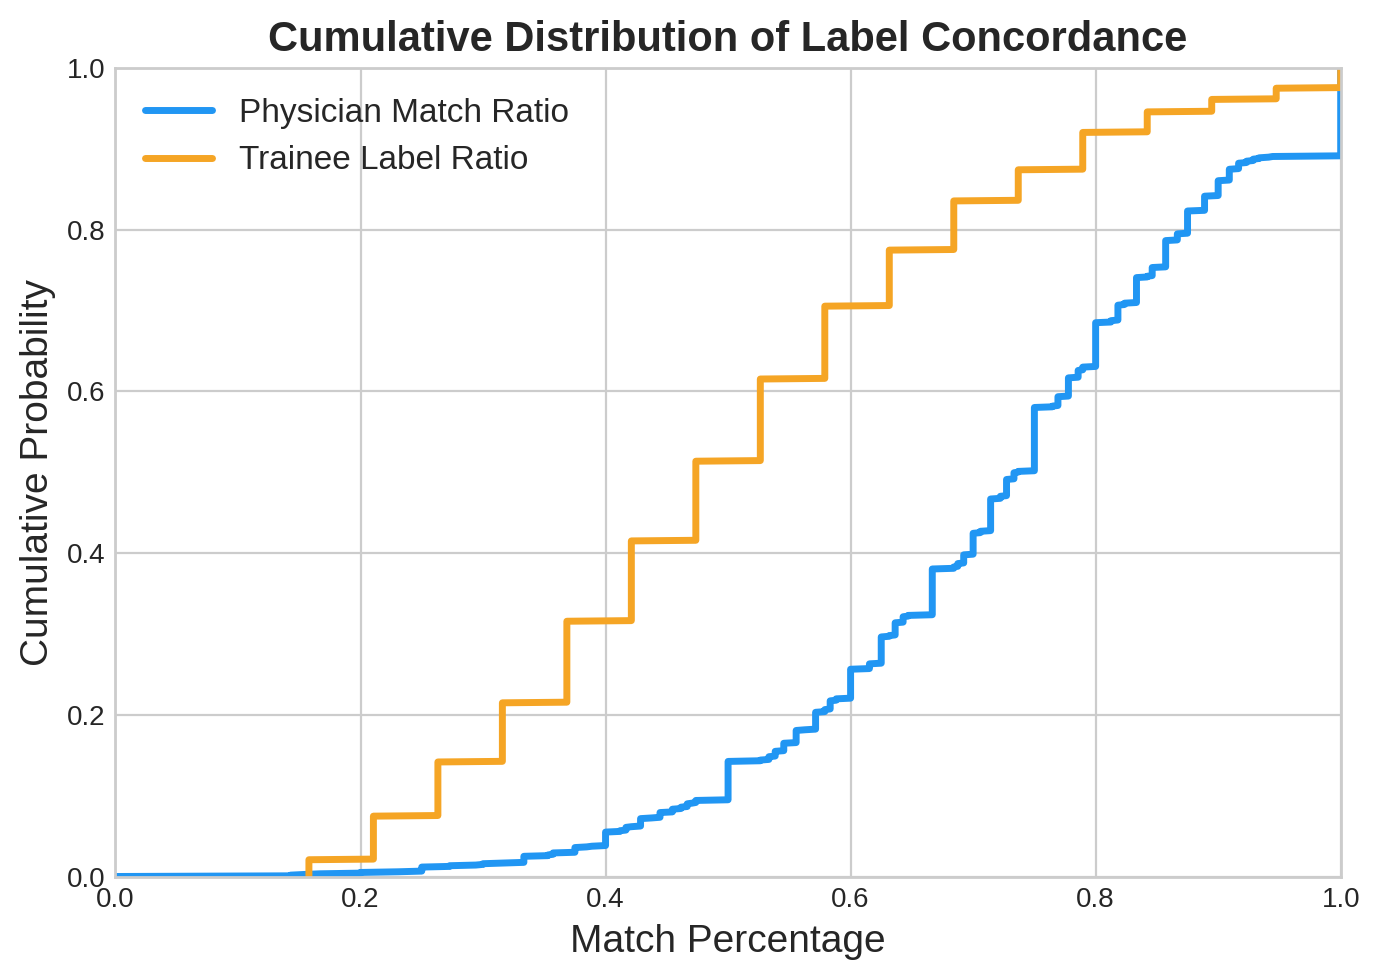

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === Convert "Match?" to numeric ratios for physician ===
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

physician["Match_Ratio"] = physician["Match?"].apply(parse_match)

# === Create numeric arrays (drop NaN) ===
ratios_physician = physician["Match_Ratio"].dropna().values
ratios_trainee = trainee[[f"q{i}" for i in range(1, 20)]].notna().sum(axis=1) / 19  # example: completeness proxy
# (If you have actual trainee match ratios, replace the above line accordingly.)

# === Sort data for CDF computation ===
x_phys = np.sort(ratios_physician)
y_phys = np.arange(1, len(x_phys) + 1) / len(x_phys)

x_trainee = np.sort(ratios_trainee)
y_trainee = np.arange(1, len(x_trainee) + 1) / len(x_trainee)

# === Plot settings ===
plt.figure(figsize=(7, 5), dpi=200)
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(x_phys, y_phys, label="Physician Match Ratio", linewidth=2.5, color="#2196F3")
plt.plot(x_trainee, y_trainee, label="Trainee Label Ratio", linewidth=2.5, color="#f5a525")

plt.xlabel("Match Percentage", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.title("Cumulative Distribution of Label Concordance", fontsize=15, weight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()

# === Save plot ===
plt.savefig("cdf_physician_vs_trainee.png", dpi=600, bbox_inches="tight")
plt.show()


In [19]:
print("Physician Mean:", np.mean(ratios_physician))
print("Trainee Mean:", np.mean(ratios_trainee))


Physician Mean: 0.7204900324016235
Trainee Mean: 0.510242914979757


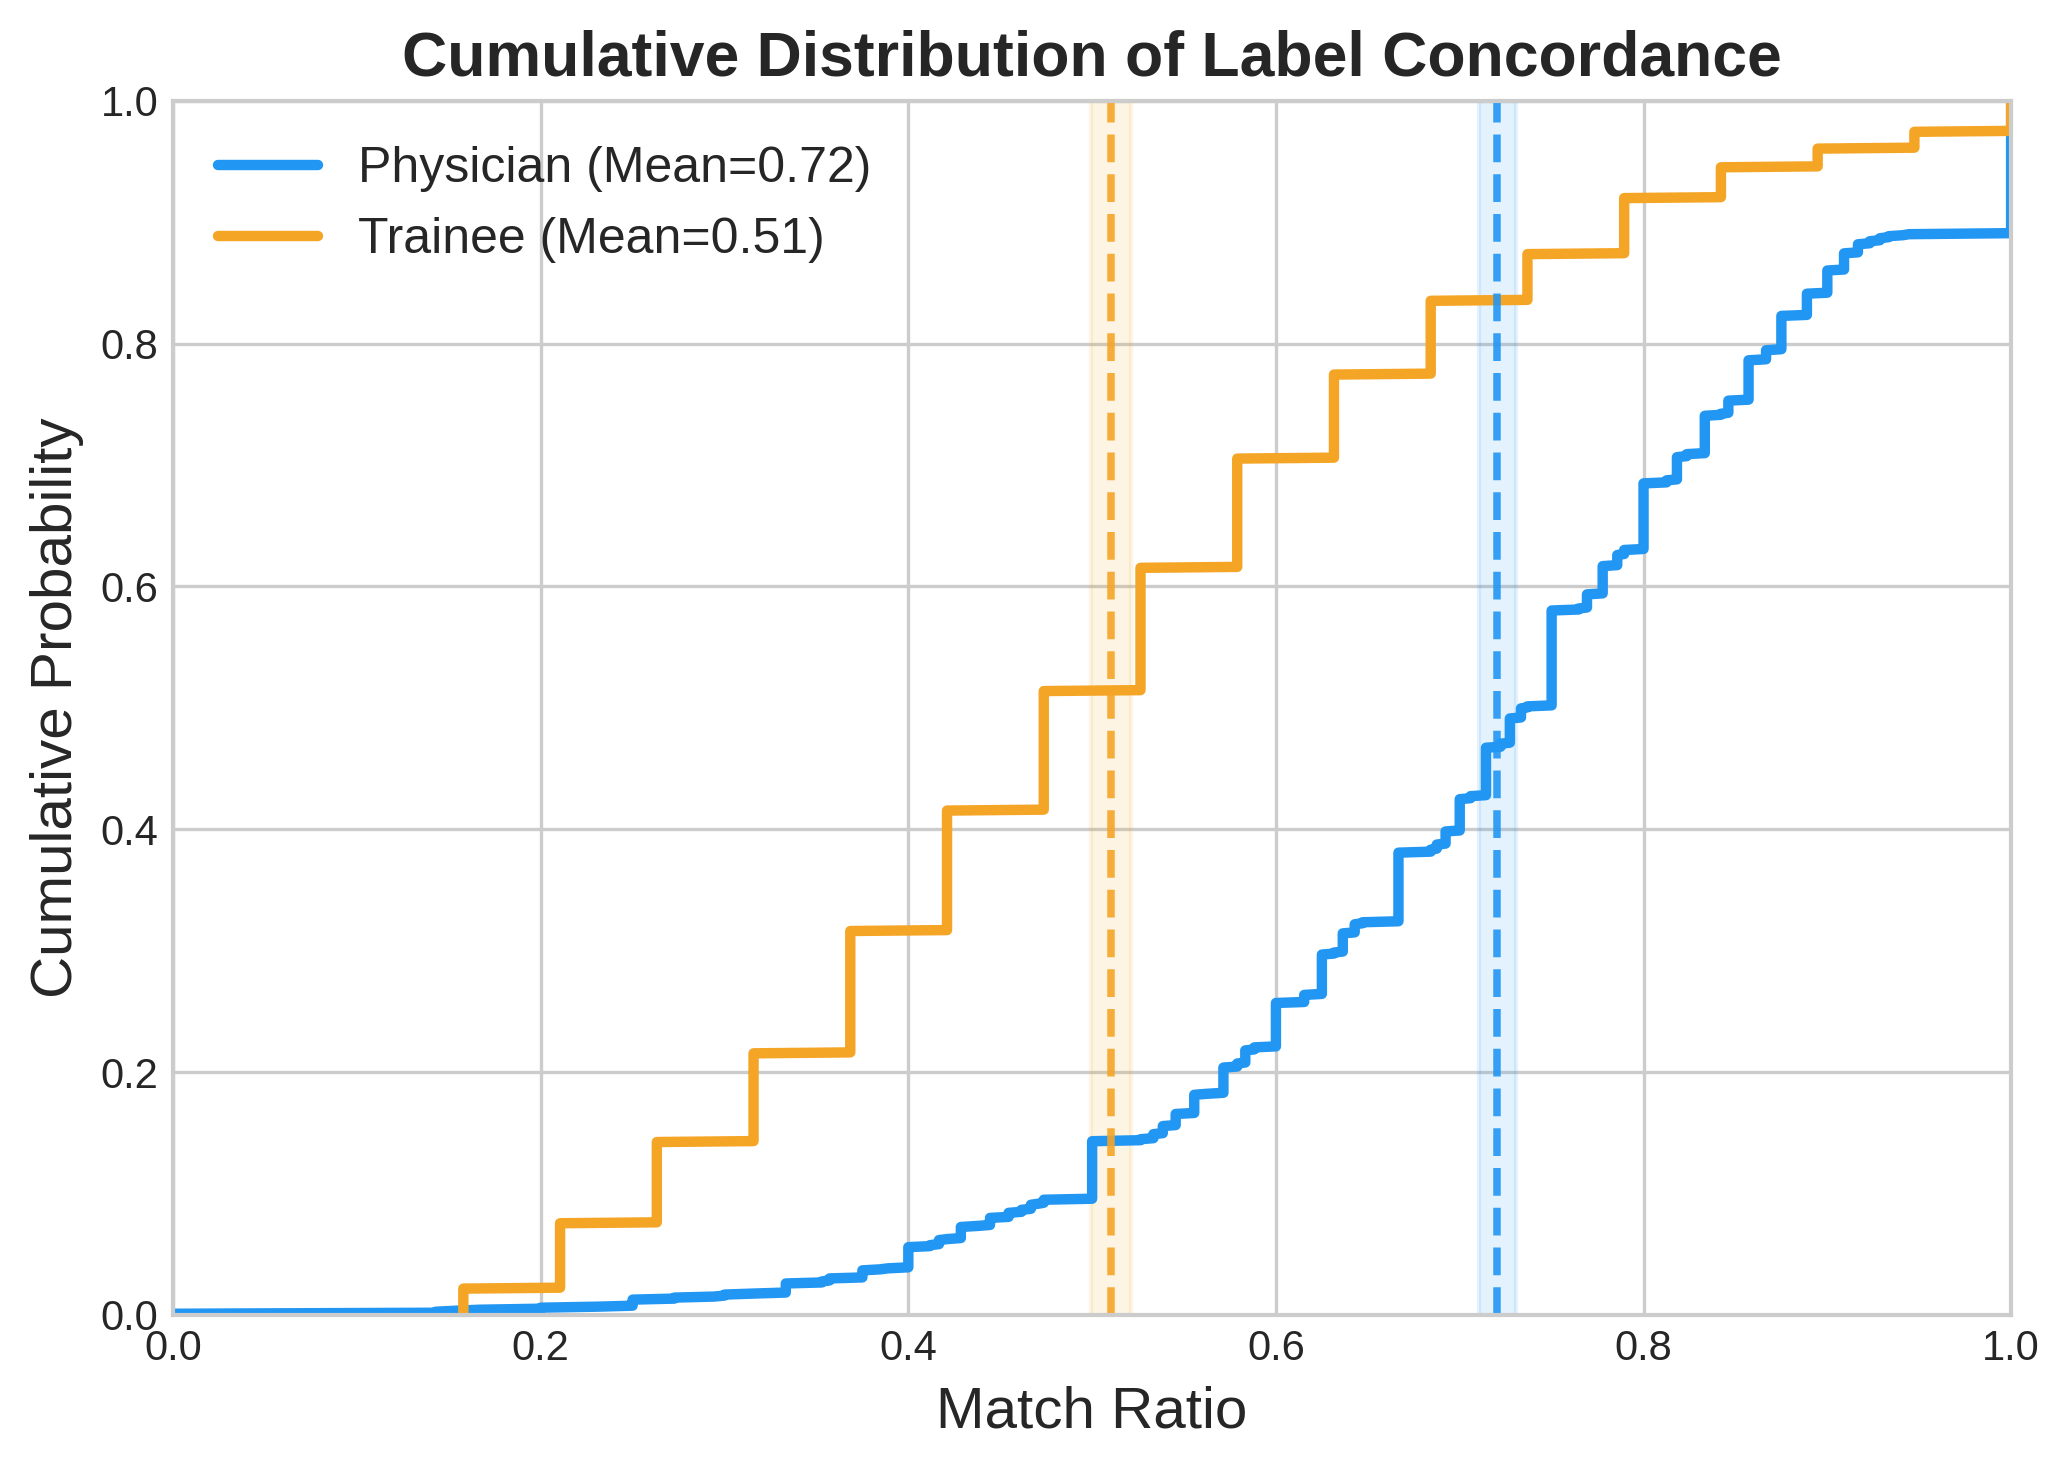

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Convert "Match?" column to numeric ratios ===
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

physician["Match_Ratio"] = physician["Match?"].apply(parse_match)
# trainee["Match_Ratio"] = trainee["Match?"].apply(parse_match)  # assuming same format for trainees

# === Drop missing values ===
ratios_phys = physician["Match_Ratio"].dropna().values
# ratios_trainee = trainee["Match_Ratio"].dropna().values

# === Compute sorted values for CDF ===
def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

x_phys, y_phys = cdf_data(ratios_phys)
x_trainee, y_trainee = cdf_data(ratios_trainee)

# === Compute mean and CI ===
def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

mean_phys, ci_phys = mean_ci(ratios_phys)
mean_trainee, ci_trainee = mean_ci(ratios_trainee)

# === Plot setup ===
plt.figure(figsize=(7,5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid")

# Colors (consistent with your previous setup)
color_phys = "#2196F3"   # blue
color_trai = "#f5a525"   # orange

# Plot CDFs
plt.plot(x_phys, y_phys, color=color_phys, linewidth=2.5, label=f"Physician (Mean={mean_phys:.2f})")
plt.plot(x_trainee, y_trainee, color=color_trai, linewidth=2.5, label=f"Trainee (Mean={mean_trainee:.2f})")

# Shaded CI regions
plt.fill_betweenx([0, 1], ci_phys[0], ci_phys[1], color=color_phys, alpha=0.12)
plt.fill_betweenx([0, 1], ci_trainee[0], ci_trainee[1], color=color_trai, alpha=0.12)

# Mean lines
plt.axvline(mean_phys, color=color_phys, linestyle='--', linewidth=1.8, alpha=0.9)
plt.axvline(mean_trainee, color=color_trai, linestyle='--', linewidth=1.8, alpha=0.9)

# Axis labels and limits
plt.xlabel("Match Ratio", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.title("Cumulative Distribution of Label Concordance", fontsize=15, weight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()

# Save high-resolution output
plt.savefig("cdf_physician_vs_trainee_CI.png", dpi=600, bbox_inches="tight")
plt.show()


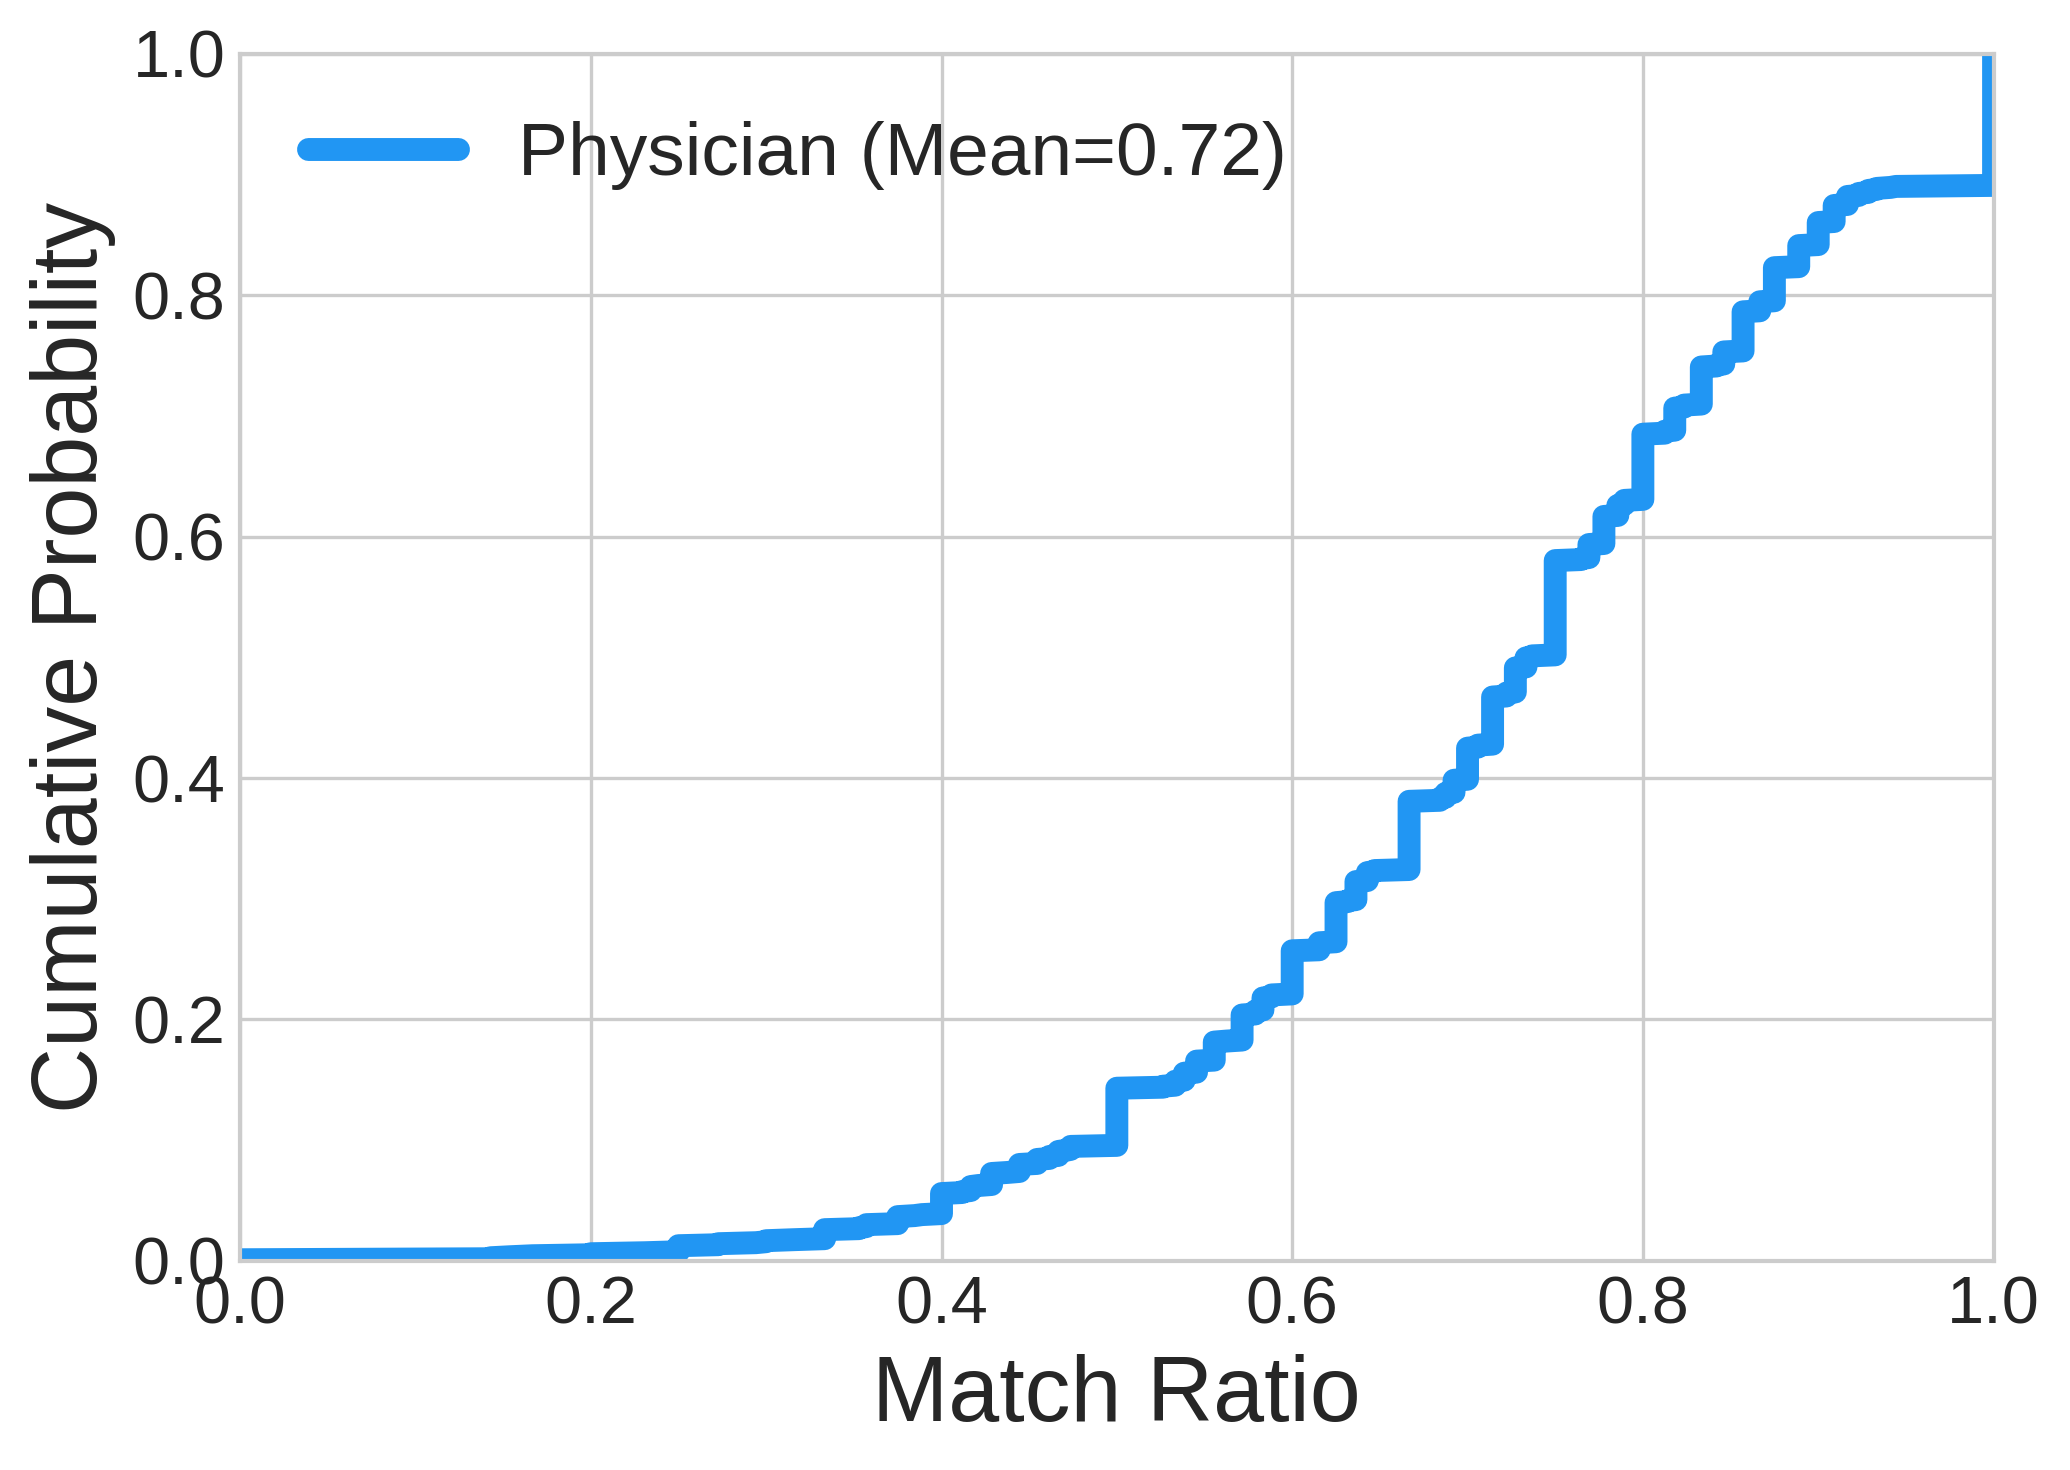

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Convert "Match?" column to numeric ratios ===
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

# Compute numeric match ratios for physician
physician["Match_Ratio"] = physician["Match?"].apply(parse_match)
ratios_phys = physician["Match_Ratio"].dropna().values

# === Compute sorted values for CDF ===
def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

x_phys, y_phys = cdf_data(ratios_phys)

# === Compute mean and 95% CI ===
def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

mean_phys, ci_phys = mean_ci(ratios_phys)

# === Plot setup ===
plt.figure(figsize=(7,5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid")

color_phys = "#2196F3"   # Physician blue

# Plot the CDF
plt.plot(x_phys, y_phys, color=color_phys, linewidth=5.5,
         label=f"Physician (Mean={mean_phys:.2f})")

# # Shaded 95% CI region
# plt.fill_betweenx([0, 1], ci_phys[0], ci_phys[1],
#                   color=color_phys, alpha=0.12)

# # Dashed mean line
# plt.axvline(mean_phys, color=color_phys, linestyle='--',
#             linewidth=1.8, alpha=0.9)

# Axis labels, title, and limits
plt.xlabel("Match Ratio", fontsize=22)
plt.ylabel("Cumulative Probability", fontsize=22)
# plt.title("Cumulative Distribution of Physician Label Concordance",
#           fontsize=15, weight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(frameon=False, fontsize=18)
plt.tight_layout()

# Save high-resolution version
plt.savefig("cdf_physician_only.png", dpi=600, bbox_inches="tight")
plt.show()


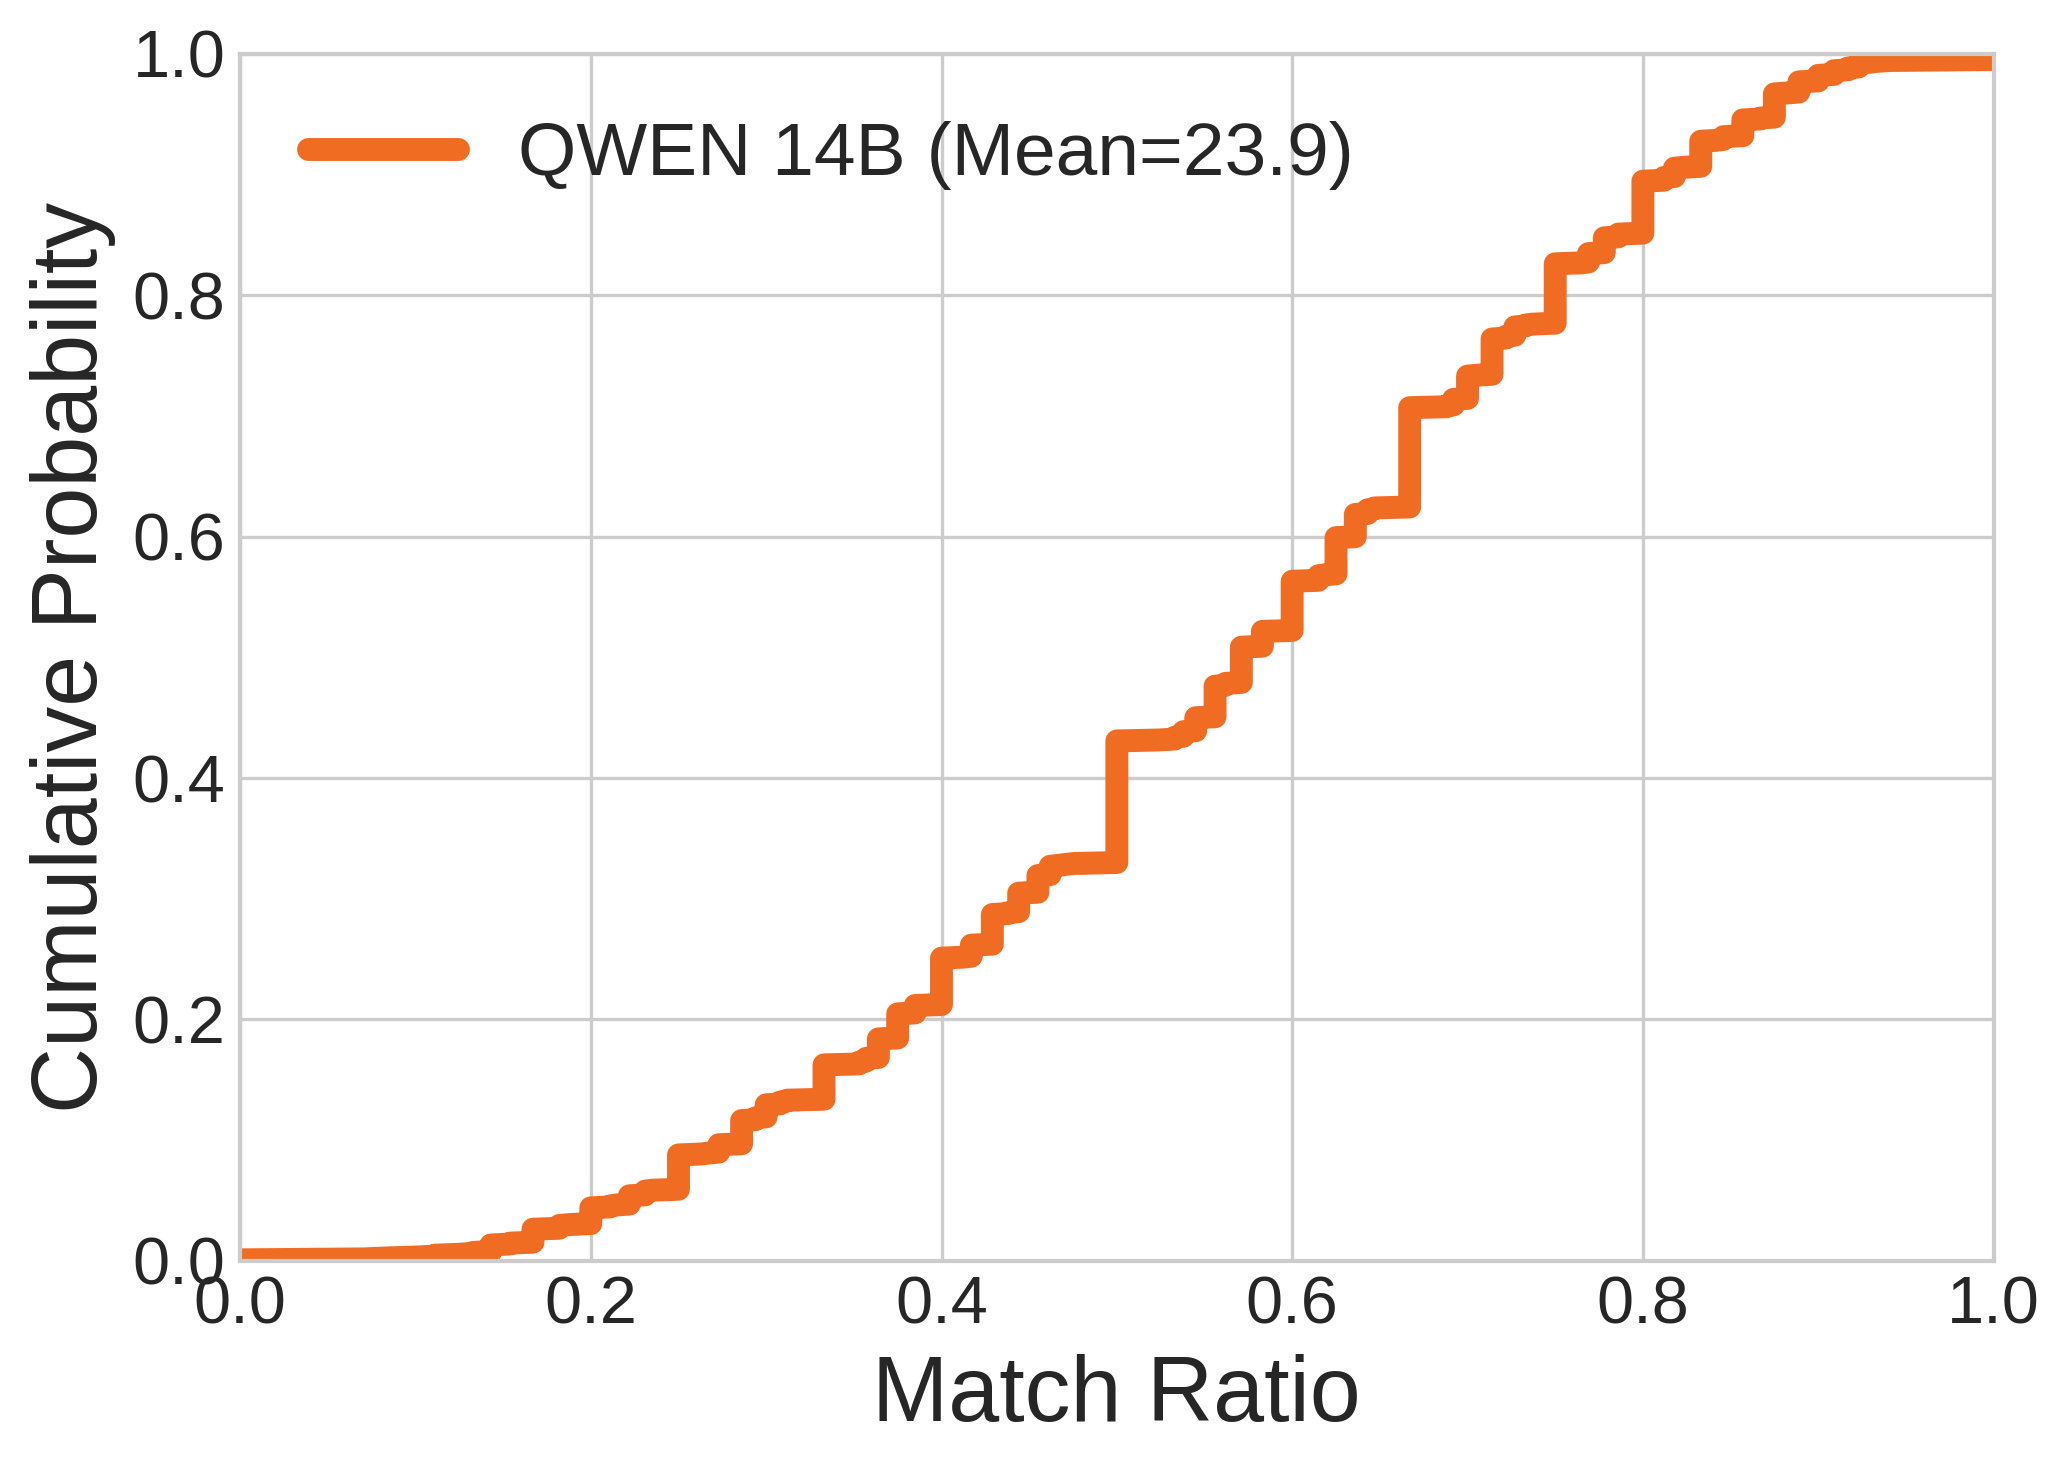

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
output_path = "results/14B_Physician_Comparison_with_Stats.csv"
QWEN14B = pd.read_csv(output_path)

# === Convert "Match?" column to numeric ratios ===
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

# Compute numeric match ratios for physician
QWEN14B["Match_Ratio"] = (
    QWEN14B["match_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
ratios_QWEN14B = QWEN14B["Match_Ratio"].dropna().values

# === Compute sorted values for CDF ===
def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

x_phys, y_phys = cdf_data(ratios_QWEN14B)

# === Compute mean and 95% CI ===
def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

mean_phys, ci_phys = mean_ci(ratios_phys)

# === Plot setup ===
plt.figure(figsize=(7,5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid")

color_QWEN14B = "#f16c23"   # Physician blue

# Plot the CDF
plt.plot(x_phys, y_phys, color=color_QWEN14B, linewidth=5.5,
         label=f"QWEN 14B (Mean=23.9)")

# # Shaded 95% CI region
# plt.fill_betweenx([0, 1], ci_phys[0], ci_phys[1],
#                   color=color_phys, alpha=0.12)

# # Dashed mean line
# plt.axvline(mean_phys, color=color_phys, linestyle='--',
#             linewidth=1.8, alpha=0.9)

# Axis labels, title, and limits
plt.xlabel("Match Ratio", fontsize=22)
plt.ylabel("Cumulative Probability", fontsize=22)
# plt.title("Cumulative Distribution of Physician Label Concordance",
#           fontsize=15, weight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(frameon=False, fontsize=18)
plt.tight_layout()

# Save high-resolution version
plt.savefig("cdf_14B_only.png", dpi=600, bbox_inches="tight")
plt.show()


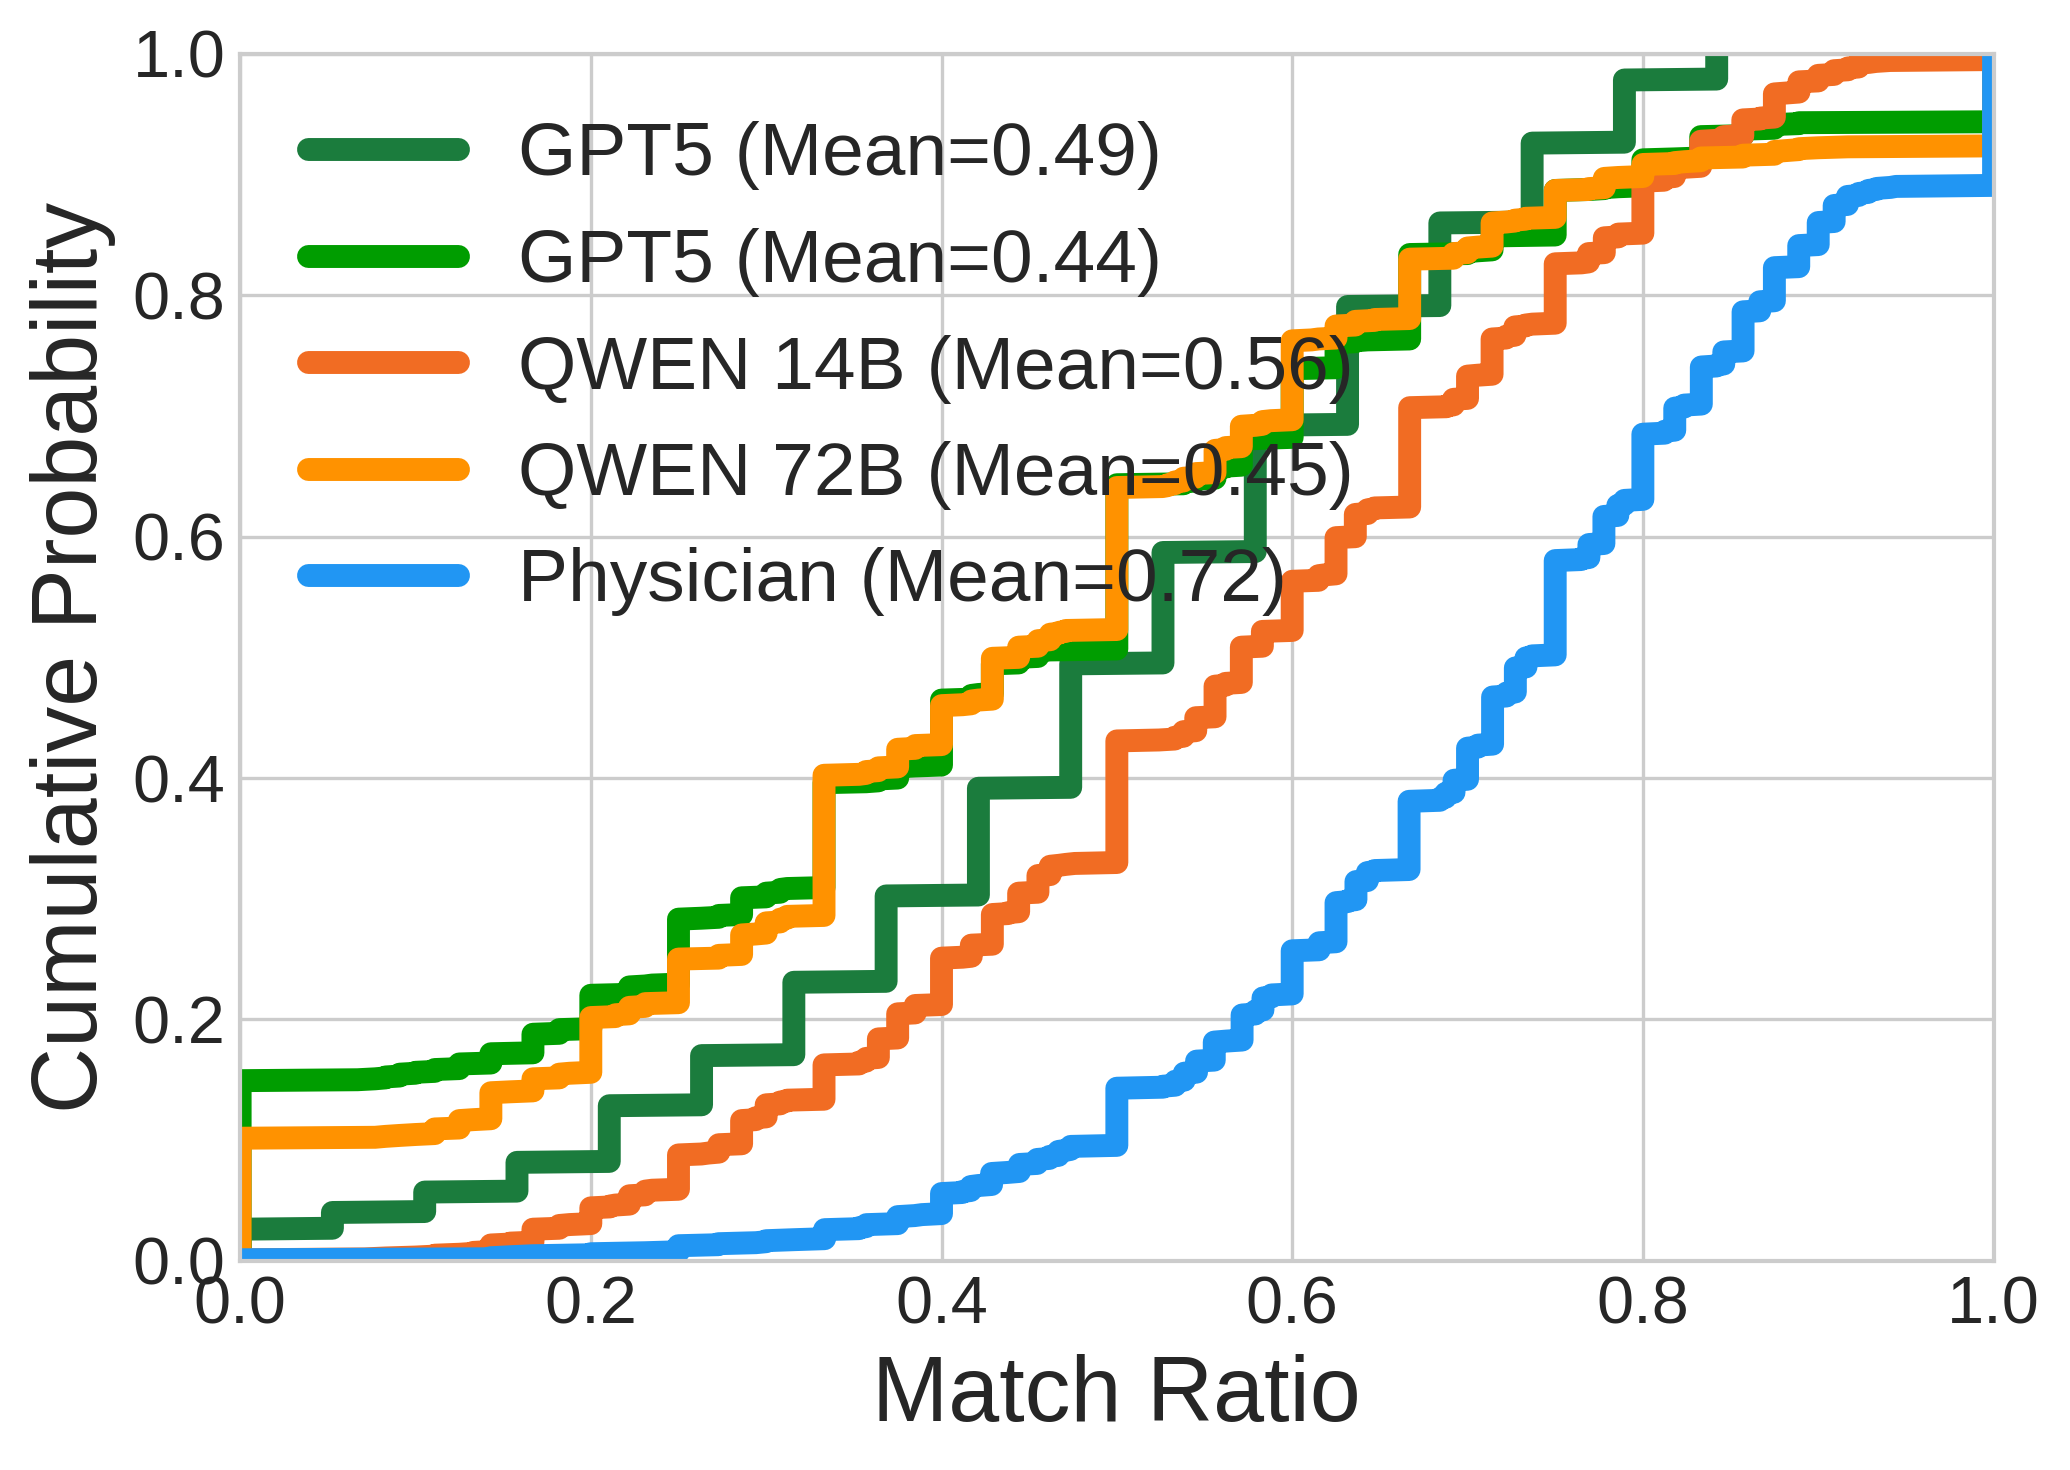

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------- Helper functions ----------
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

# ---------- GPT5 ----------
GPT5 = pd.read_csv("results/GPT5_MatchRate.csv")
GPT5["Match_Ratio"] = GPT5["Match?"].apply(parse_match)
ratios_gpt5 = GPT5["Match_Ratio"].dropna().values
x_gpt5, y_gpt5 = cdf_data(ratios_gpt5)
mean_gpt5, _ = mean_ci(ratios_gpt5)

# ---------- GPT4o ----------
GPT4o = pd.read_csv("results/GPT4o_MatchRate.csv")
GPT4o["Match_Ratio"] = (
    GPT4o["match_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
ratios_gpt4o = GPT4o["Match_Ratio"].dropna().values
x_gpt4o, y_gpt4o = cdf_data(ratios_gpt4o)
mean_gpt4o, _ = mean_ci(ratios_gpt4o)

# ---------- QWEN 14B ----------
QWEN14B = pd.read_csv("results/14B_Physician_Comparison_with_Stats.csv")
QWEN14B["Match_Ratio"] = (
    QWEN14B["match_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
ratios_qwen = QWEN14B["Match_Ratio"].dropna().values
x_qwen, y_qwen = cdf_data(ratios_qwen)
mean_qwen, _ = mean_ci(ratios_qwen)

# ---------- QWEN 72B ----------
QWEN72B = pd.read_csv("results/72B_MatchRate.csv")
QWEN72B["Match_Ratio"] = (
    QWEN72B["match_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(1)
    .round(3)
)
ratios_qwen72 = QWEN72B["Match_Ratio"].dropna().values
x_qwen72, y_qwen72 = cdf_data(ratios_qwen72)
mean_qwen72, _ = mean_ci(ratios_qwen72)

# ---------- Physician ----------
physician["Match_Ratio"] = physician["Match?"].apply(parse_match)
ratios_phys = physician["Match_Ratio"].dropna().values
x_phys, y_phys = cdf_data(ratios_phys)
mean_phys, _ = mean_ci(ratios_phys)

# ---------- Combined plot ----------
plt.figure(figsize=(7, 5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(
    x_gpt5, y_gpt5,
    color="#1b7c3d", linewidth=5.5,
    label=f"GPT5 (Mean={mean_gpt5:.2f})"
)

plt.plot(
    x_gpt4o, y_gpt4o,
    color="#009d00", linewidth=5.5,
    label=f"GPT5 (Mean={mean_gpt4o:.2f})"
)

plt.plot(
    x_qwen, y_qwen,
    color="#f16c23", linewidth=5.5,
    label=f"QWEN 14B (Mean={mean_qwen:.2f})"
)

plt.plot(
    x_qwen72, y_qwen72,
    color="#ff9200", linewidth=5.5,
    label=f"QWEN 72B (Mean={mean_qwen72:.2f})"
)

plt.plot(
    x_phys, y_phys,
    color="#2196F3", linewidth=5.5,
    label=f"Physician (Mean={mean_phys:.2f})"
)

plt.xlabel("Match Ratio", fontsize=22)
plt.ylabel("Cumulative Probability", fontsize=22)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(frameon=False, fontsize=18)

plt.tight_layout()
plt.savefig("cdf_qwen_vs_physician.png", dpi=600, bbox_inches="tight")
plt.show()


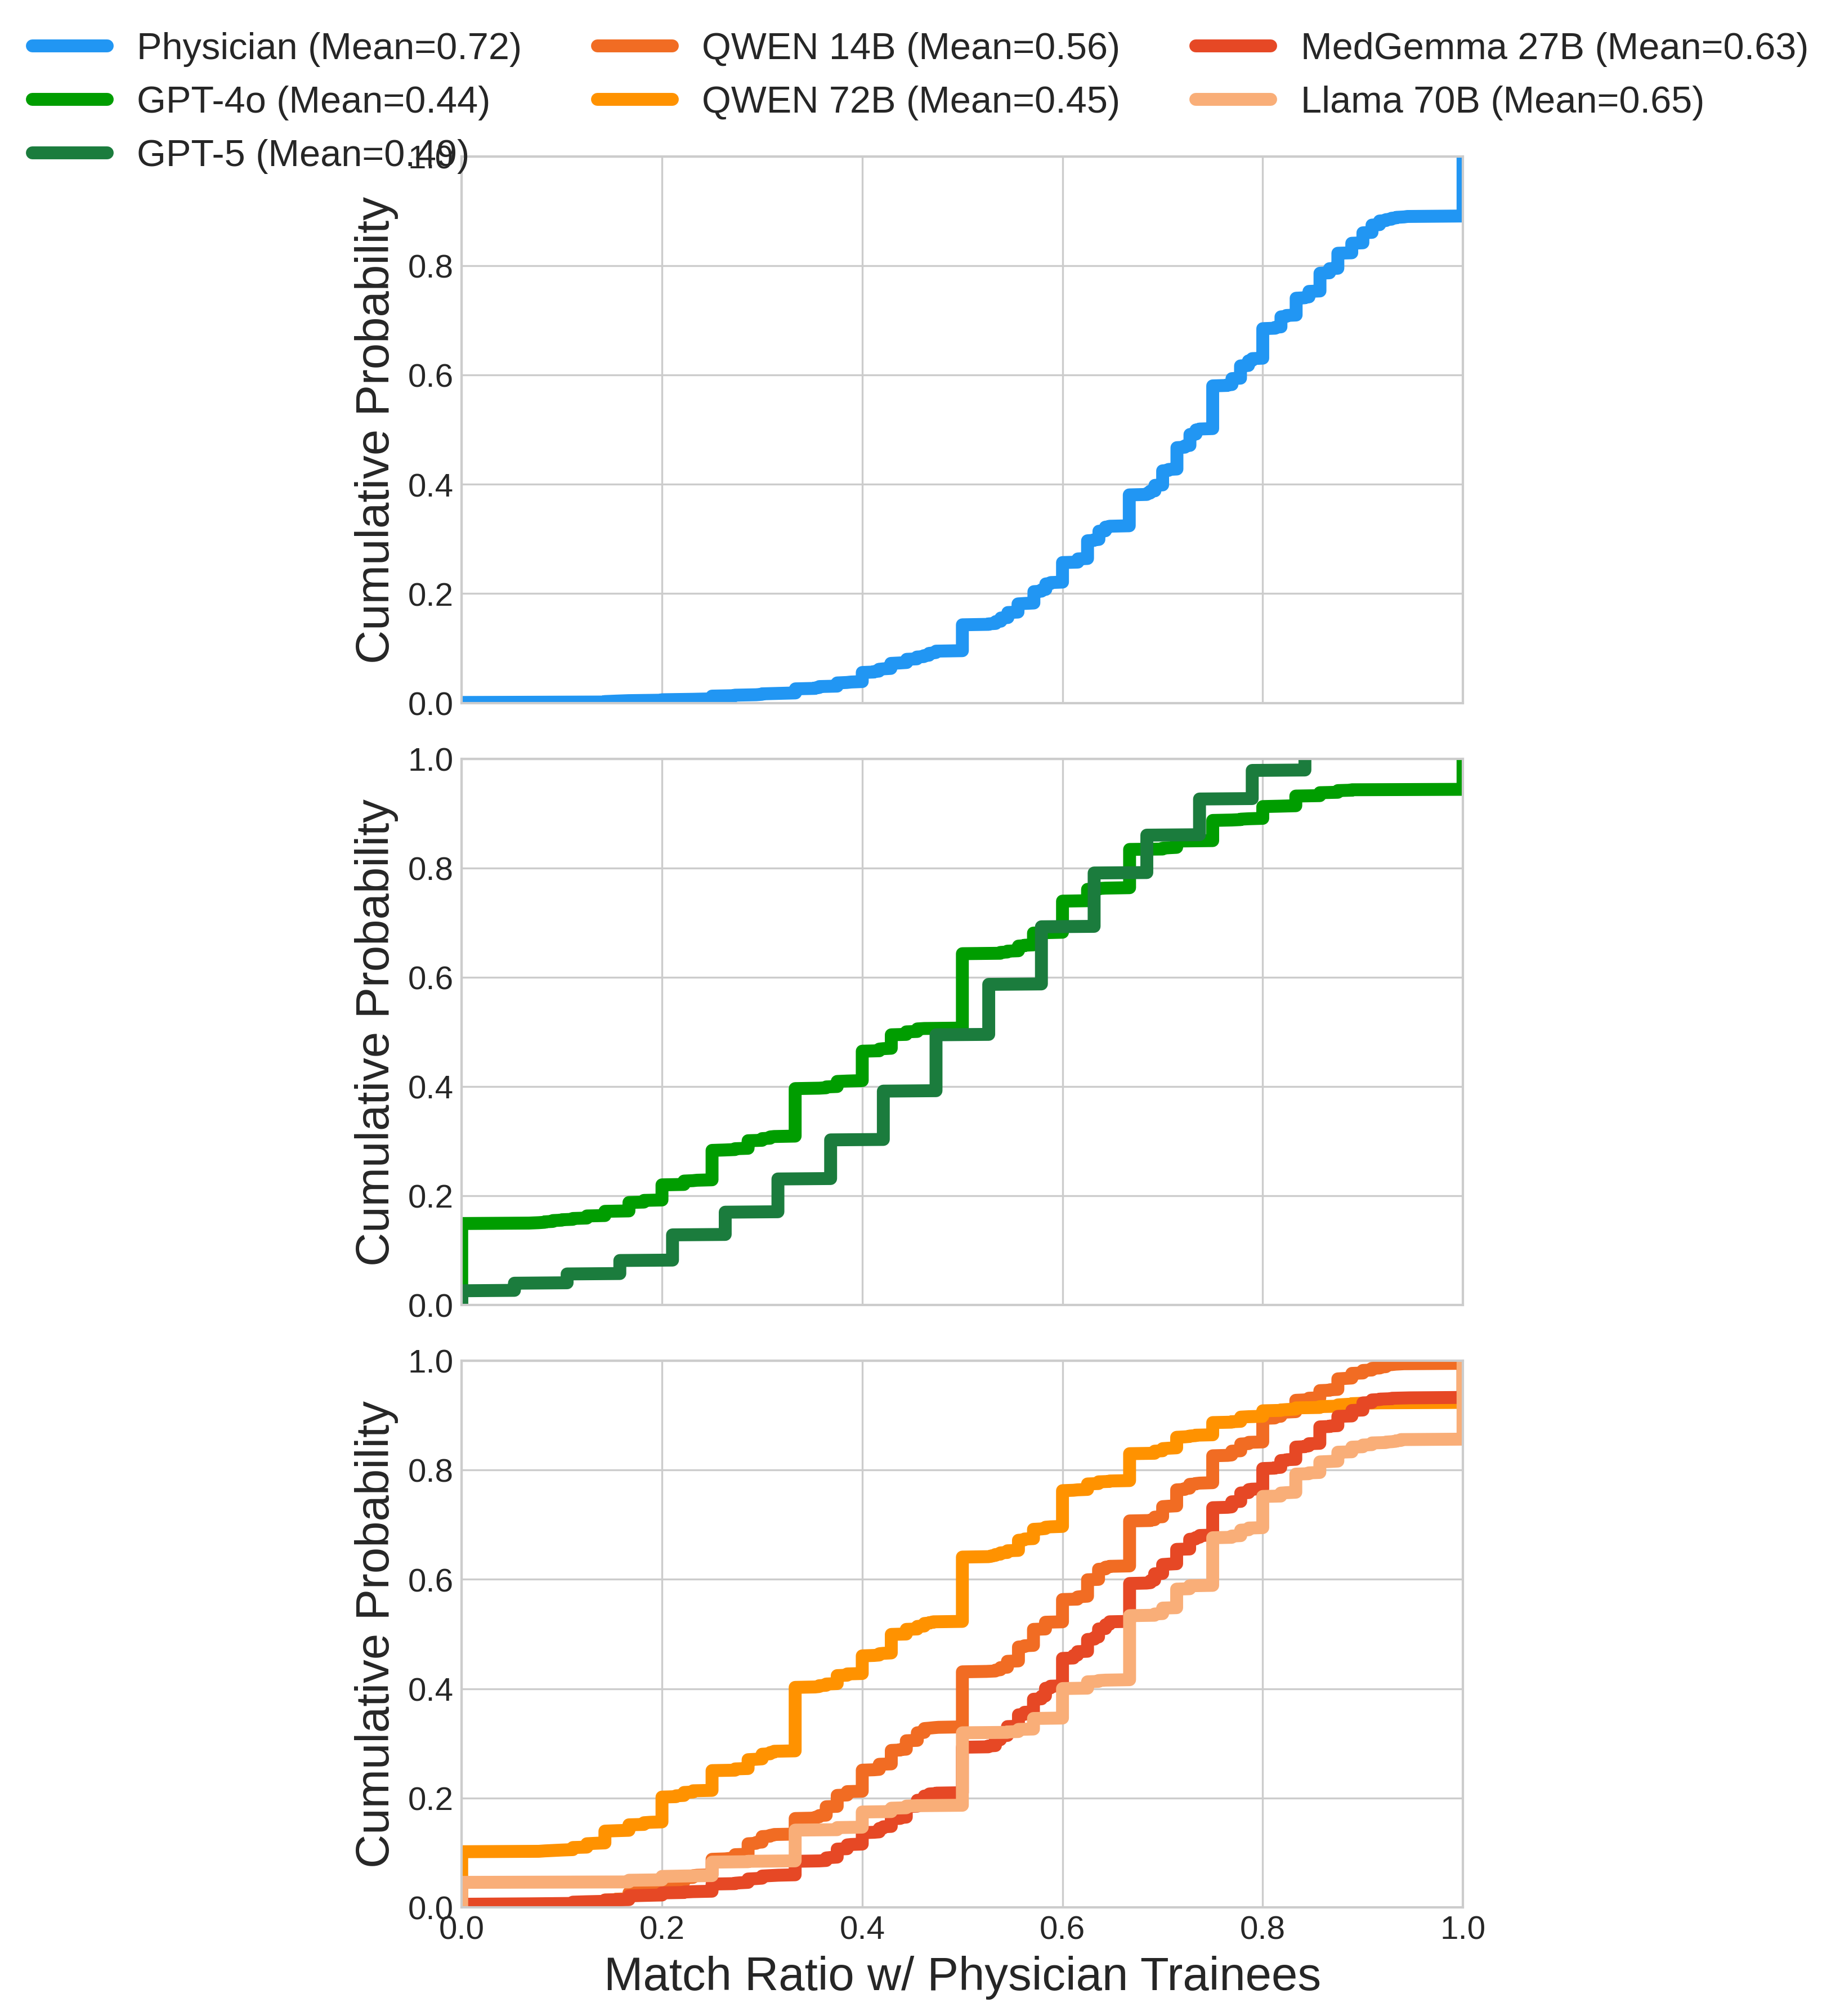

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------- Helper functions ----------
def parse_match(value):
    if pd.isna(value):
        return np.nan
    if value == 1:
        return 1.0
    if isinstance(value, str) and "/" in value:
        num, denom = value.split("/")
        try:
            return float(num) / float(denom)
        except:
            return np.nan
    return np.nan

def cdf_data(data):
    data_sorted = np.sort(data)
    yvals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, yvals

def mean_ci(data):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n)
    return mean, (mean - margin, mean + margin)

# ---------- Load and preprocess data ----------

# GPT-5
GPT5 = pd.read_csv("results/GPT5_MatchRate.csv")
GPT5["Match_Ratio"] = GPT5["Match?"].apply(parse_match)
x_gpt5, y_gpt5 = cdf_data(GPT5["Match_Ratio"].dropna().values)
mean_gpt5, _ = mean_ci(GPT5["Match_Ratio"].dropna().values)

# GPT-4o
GPT4o = pd.read_csv("results/GPT4o_MatchRate.csv")
GPT4o["Match_Ratio"] = (
    GPT4o["match_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
x_gpt4o, y_gpt4o = cdf_data(GPT4o["Match_Ratio"].dropna().values)
mean_gpt4o, _ = mean_ci(GPT4o["Match_Ratio"].dropna().values)

# Llama 70B
LLAMA70B = pd.read_csv("results/70B_MatchRate.csv")
LLAMA70B["Match_Ratio"] = (
    LLAMA70B["Match_Rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(1)
    .round(3)
)
x_llama70, y_llama70 = cdf_data(LLAMA70B["Match_Ratio"].dropna().values)
mean_llama70, _ = mean_ci(LLAMA70B["Match_Ratio"].dropna().values)

# QWEN 14B
QWEN14B = pd.read_csv("results/14B_Physician_Comparison_with_Stats.csv")
QWEN14B["Match_Ratio"] = (
    QWEN14B["match_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
    .div(100)
    .round(3)
)
x_qwen14, y_qwen14 = cdf_data(QWEN14B["Match_Ratio"].dropna().values)
mean_qwen14, _ = mean_ci(QWEN14B["Match_Ratio"].dropna().values)

# QWEN 72B
QWEN72B = pd.read_csv("results/72B_MatchRate.csv")
QWEN72B["Match_Ratio"] = QWEN72B["match_rate"].astype(float).round(3)
x_qwen72, y_qwen72 = cdf_data(QWEN72B["Match_Ratio"].dropna().values)
mean_qwen72, _ = mean_ci(QWEN72B["Match_Ratio"].dropna().values)

# MedGemma 27B
MedGemma27B = pd.read_csv("results/MedGemma_SR_Match_Rate.csv")
MedGemma27B["Match_Ratio"] = (MedGemma27B["Match_percent"]/100).astype(float).round(3)
x_gemma, y_gemma = cdf_data(MedGemma27B["Match_Ratio"].dropna().values)
mean_gemma, _ = mean_ci(MedGemma27B["Match_Ratio"].dropna().values)

# Physician
physician["Match_Ratio"] = physician["Match?"].apply(parse_match)
x_phys, y_phys = cdf_data(physician["Match_Ratio"].dropna().values)
mean_phys, _ = mean_ci(physician["Match_Ratio"].dropna().values)

# ---------- Plotting ----------
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(7, 12), dpi=300, sharex=True, sharey=True)

# Subplot 1: Physician
axes[0].plot(
    x_phys, y_phys,
    color="#2196F3", linewidth=5.5,
    label=f"Physician (Mean={mean_phys:.2f})"
)
axes[0].set_ylabel("Cumulative Probability", fontsize=20)

# Subplot 2: GPT models
axes[1].plot(
    x_gpt4o, y_gpt4o,
    color="#009d00", linewidth=5.5,
    label=f"GPT-4o (Mean={mean_gpt4o:.2f})"
)
axes[1].plot(
    x_gpt5, y_gpt5,
    color="#1b7c3d", linewidth=5.5,
    label=f"GPT-5 (Mean={mean_gpt5:.2f})"
)
axes[1].set_ylabel("Cumulative Probability", fontsize=20)

# Subplot 3: QWEN models
axes[2].plot(
    x_qwen14, y_qwen14,
    color="#f16c23", linewidth=5.5,
    label=f"QWEN 14B (Mean={mean_qwen14:.2f})"
)
axes[2].plot(
    x_qwen72, y_qwen72,
    color="#ff9200", linewidth=5.5,
    label=f"QWEN 72B (Mean={mean_qwen72:.2f})"
)
axes[2].plot(
    x_gemma, y_gemma,
    color="#E64825", linewidth=5.5,
    label=f"MedGemma 27B (Mean={mean_gemma:.2f})"
)
axes[2].plot(
    x_llama70, y_llama70,
    color="#f9AE78", linewidth=5.5,
    label=f"Llama 70B (Mean={mean_llama70:.2f})"
)
axes[2].set_xlabel("Match Ratio w/ Physician Trainees", fontsize=20)
axes[2].set_ylabel("Cumulative Probability", fontsize=20)

# Axis formatting
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=14)

# Shared legend at the top
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 1)
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("cdf_comparison_subplots.pdf", dpi=600, bbox_inches="tight")
plt.show()


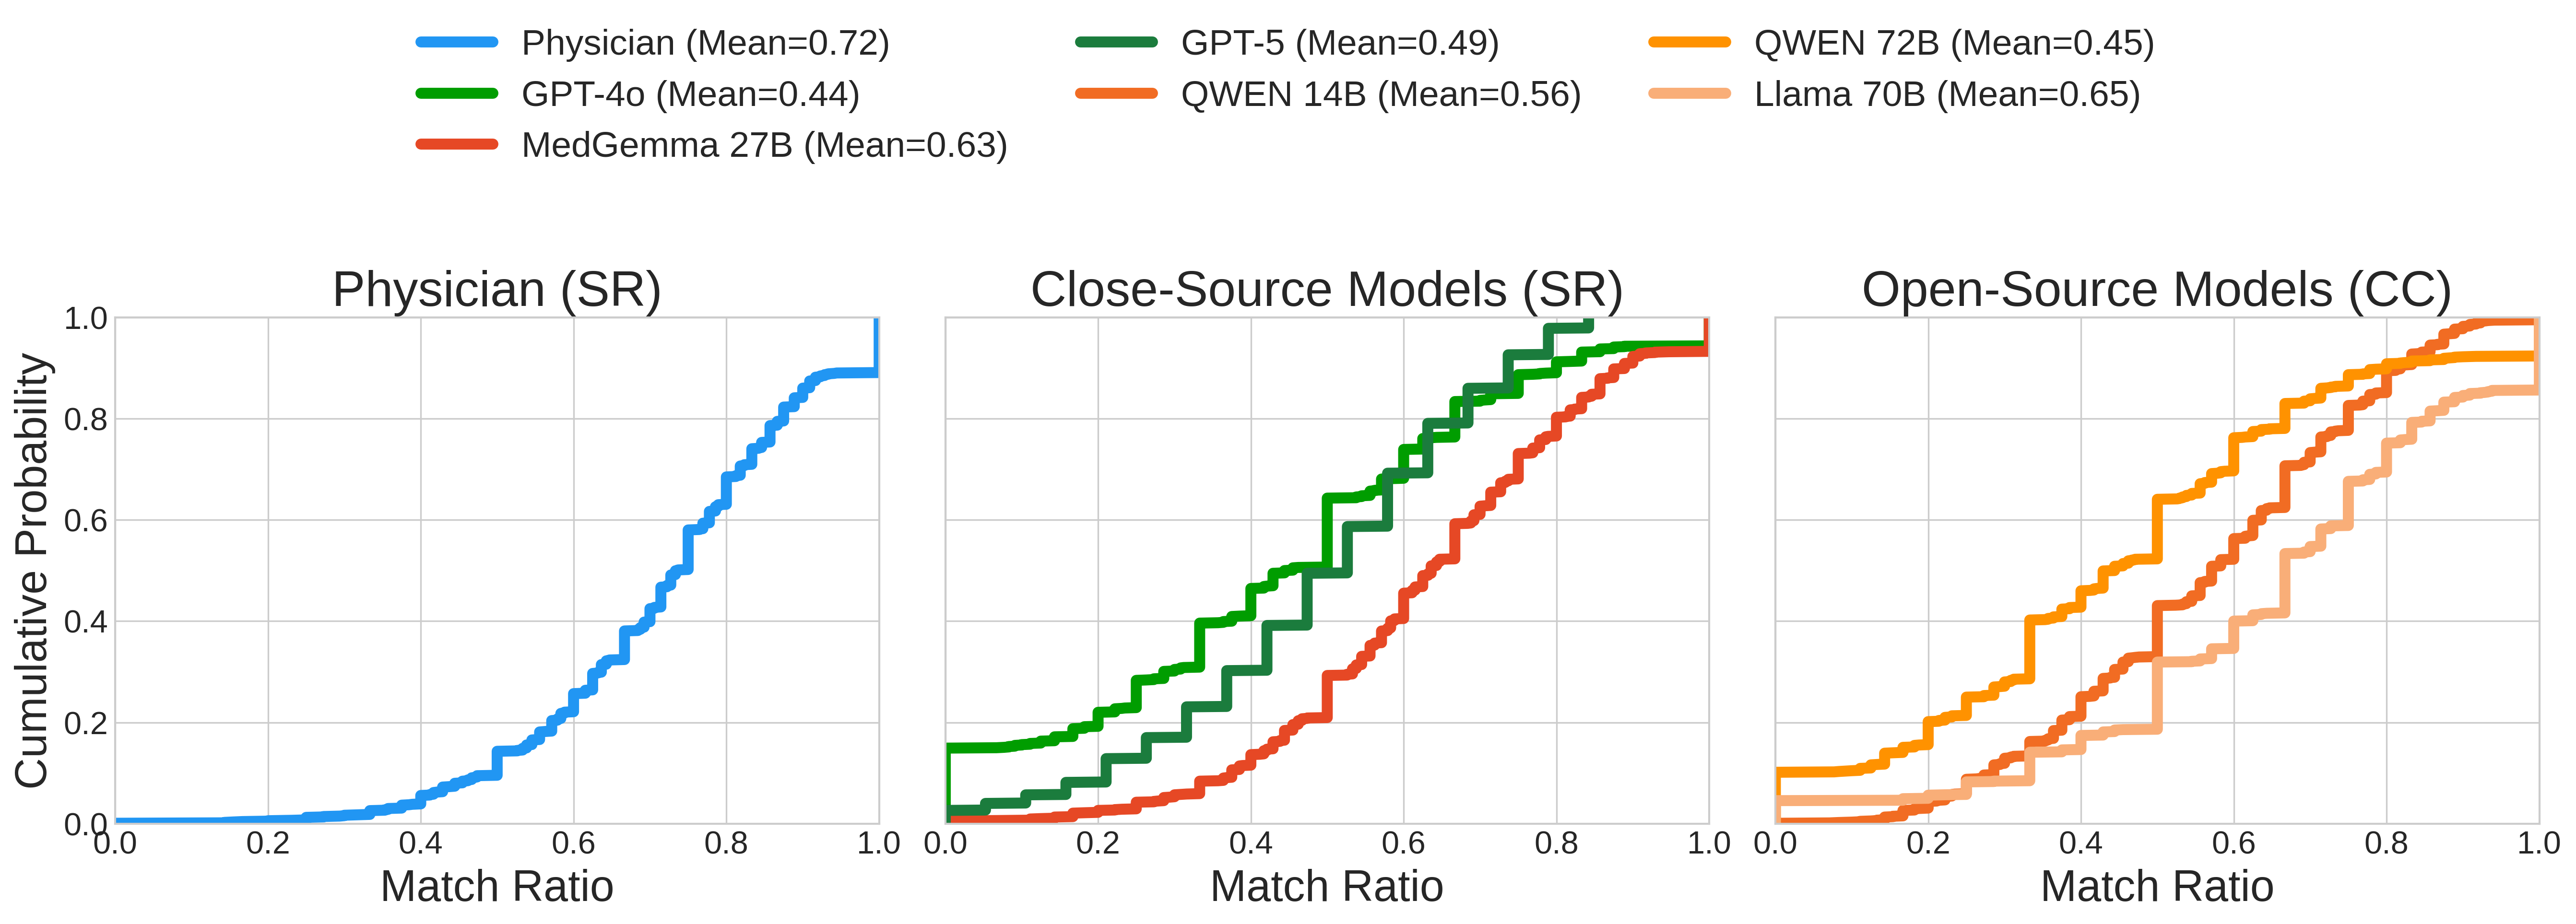

In [25]:
# ---------- Plotting ----------
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    dpi=300,
    sharey=True
)

# ---------- Subplot 1: Physician ----------
axes[0].plot(
    x_phys, y_phys,
    color="#2196F3", linewidth=5.5,
    label=f"Physician (Mean={mean_phys:.2f})"
)
axes[0].set_xlabel("Match Ratio", fontsize=22)
axes[0].set_ylabel("Cumulative Probability", fontsize=22)
axes[0].set_title("Physician (SR)", fontsize=25)

# ---------- Subplot 2: GPT models ----------
axes[1].plot(
    x_gpt4o, y_gpt4o,
    color="#009d00", linewidth=5.5,
    label=f"GPT-4o (Mean={mean_gpt4o:.2f})"
)
axes[1].plot(
    x_gemma, y_gemma,
    color="#E64825", linewidth=5.5,
    label=f"MedGemma 27B (Mean={mean_gemma:.2f})"
)
axes[1].plot(
    x_gpt5, y_gpt5,
    color="#1b7c3d", linewidth=5.5,
    label=f"GPT-5 (Mean={mean_gpt5:.2f})"
)
axes[1].set_xlabel("Match Ratio", fontsize=22)
axes[1].set_title("Close-Source Models (SR)", fontsize=25)

# ---------- Subplot 3: QWEN models ----------
axes[2].plot(
    x_qwen14, y_qwen14,
    color="#f16c23", linewidth=5.5,
    label=f"QWEN 14B (Mean={mean_qwen14:.2f})"
)
axes[2].plot(
    x_qwen72, y_qwen72,
    color="#ff9200", linewidth=5.5,
    label=f"QWEN 72B (Mean={mean_qwen72:.2f})"
)
axes[2].plot(
    x_llama70, y_llama70,
    color="#f9AE78", linewidth=5.5,
    label=f"Llama 70B (Mean={mean_llama70:.2f})"
)
axes[2].set_xlabel("Match Ratio", fontsize=22)
axes[2].set_title("Open-Source Models (CC)", fontsize=25)

# ---------- Axis formatting ----------
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=16)

# ---------- Single-row legend ----------
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels) / 2,     # force one-row legend
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 1.3)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("CNF.png", dpi=600, bbox_inches="tight")
plt.show()


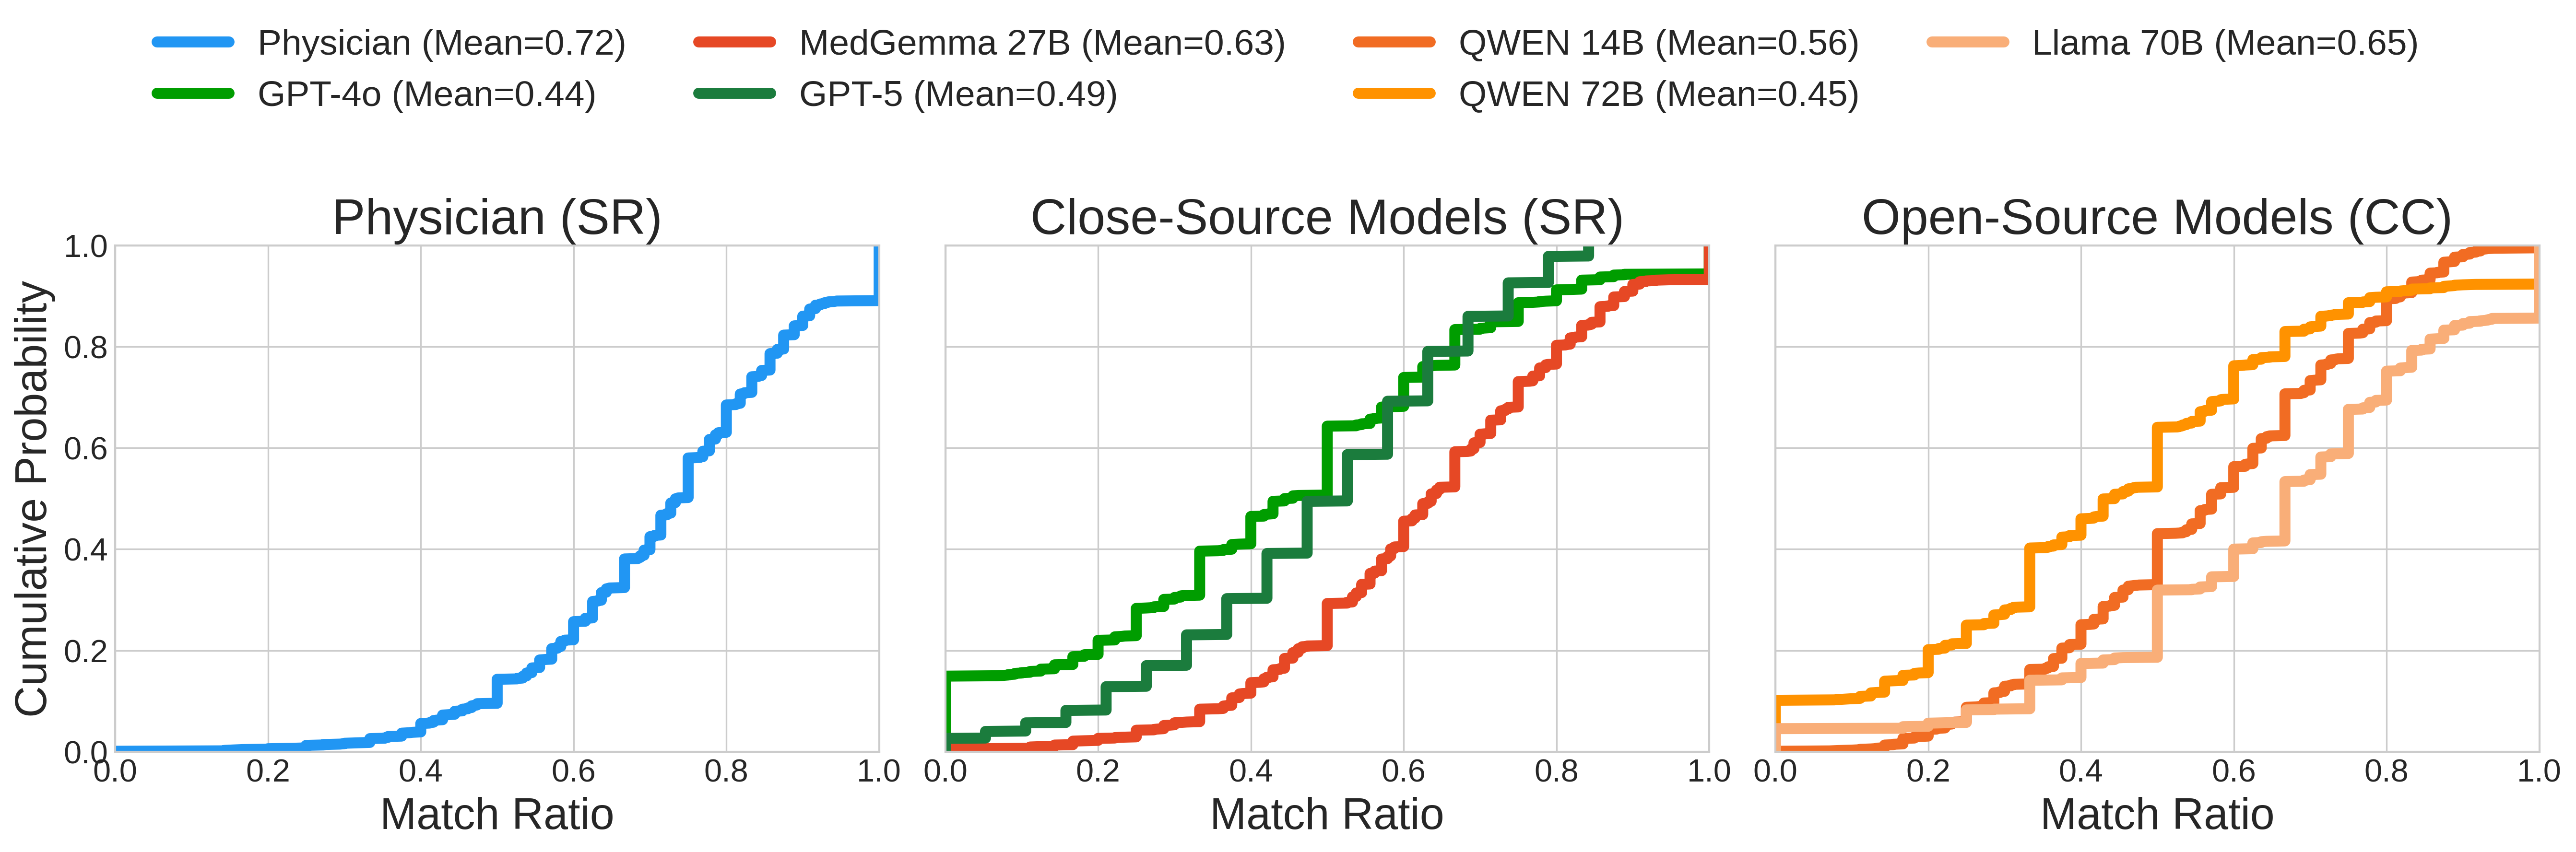

In [26]:
# ---------- Plotting ----------
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    dpi=300,
    sharey=True
)
# ---------- Subplot 1: Physician ----------
line_phys, = axes[0].plot(
    x_phys, y_phys,
    color="#2196F3", linewidth=5.5,
    label=f"Physician (Mean={mean_phys:.2f})"
)
axes[0].set_xlabel("Match Ratio", fontsize=22)
axes[0].set_ylabel("Cumulative Probability", fontsize=22)
axes[0].set_title("Physician (SR)", fontsize=25)

# ---------- Subplot 2: GPT models ----------
line_gpt4o, = axes[1].plot(
    x_gpt4o, y_gpt4o,
    color="#009d00", linewidth=5.5,
    label=f"GPT-4o (Mean={mean_gpt4o:.2f})"
)
line_gemma, = axes[1].plot(
    x_gemma, y_gemma,
    color="#E64825", linewidth=5.5,
    label=f"MedGemma 27B (Mean={mean_gemma:.2f})"
)
line_gpt5, = axes[1].plot(
    x_gpt5, y_gpt5,
    color="#1b7c3d", linewidth=5.5,
    label=f"GPT-5 (Mean={mean_gpt5:.2f})"
)
axes[1].set_xlabel("Match Ratio", fontsize=22)
axes[1].set_title("Close-Source Models (SR)", fontsize=25)

# ---------- Subplot 3: QWEN models ----------
line_qwen14, = axes[2].plot(
    x_qwen14, y_qwen14,
    color="#f16c23", linewidth=5.5,
    label=f"QWEN 14B (Mean={mean_qwen14:.2f})"
)
line_qwen72, = axes[2].plot(
    x_qwen72, y_qwen72,
    color="#ff9200", linewidth=5.5,
    label=f"QWEN 72B (Mean={mean_qwen72:.2f})"
)
line_llama70, = axes[2].plot(
    x_llama70, y_llama70,
    color="#f9AE78", linewidth=5.5,
    label=f"Llama 70B (Mean={mean_llama70:.2f})"
)
axes[2].set_xlabel("Match Ratio", fontsize=22)
axes[2].set_title("Open-Source Models (CC)", fontsize=25)

# ---------- Axis formatting ----------
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=16)

# ---------- Manually ordered legend ----------
handles = [line_phys, line_gpt4o, line_gemma, line_gpt5, line_qwen14, line_qwen72, line_llama70]
labels = [h.get_label() for h in handles]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,     # all in one row
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 1.2)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("CNF.png", dpi=600, bbox_inches="tight")
plt.show()